In [18]:
from utility.plot_spectrum import plot_spectrum
from utility.adjust_redshift import adjust_redshift
from utility.my_colors import palette_light, pink

from processing.remove_spikes import remove_spikes
from processing.fit_continuum import fit_continuum
from processing.quality_cuts import quality_cuts
from processing.make_bal_mask import make_bal_mask
from processing.fit_gaussians import fit_single_gaussian, fit_two_gaussians, ftest_which_gaussian
from processing.measure_line import measure_line

from sparcl.client import SparclClient
from dl import queryClient as qc
from astropy.table import Table
from astropy.convolution import convolve, Gaussian1DKernel
from scipy.interpolate import interp1d

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings

hamann_fits_path = "data/local/ERQs_core_all_MNRAS.fits"
search_log_path = "data/local/hamann-objects-desi-search-log.json"

In [19]:
hamann_data = Table.read("data/local/ERQs_core_all_MNRAS.fits").to_pandas() #pd.read_csv(hamann_erq_path,index_col=0)

hamann_data["sdss_name"] = hamann_data["sdss_name"].astype("string")

match_df = pd.read_json(search_log_path)
match_df = match_df[["SDSS_id","best_match_id"]].copy()
match_df["SDSS_id"] = match_df["SDSS_id"].str[1:]

match_df = match_df.rename(columns={"best_match_id":"targetid", "SDSS_id":"sdss_name"})

hamann_erq = hamann_data.merge(match_df,on="sdss_name",how="left")

hamann_erq.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97 entries, 0 to 96
Data columns (total 47 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sdss_name    97 non-null     object 
 1   Plate        97 non-null     int32  
 2   MJD          97 non-null     int32  
 3   FiberID      97 non-null     int32  
 4   ThingID      97 non-null     int32  
 5   z_dr12       97 non-null     float64
 6   i            97 non-null     float64
 7   i_err        97 non-null     float64
 8   W3           97 non-null     float64
 9   W3_snr       97 non-null     float64
 10  cc_flags     97 non-null     object 
 11  bal_flag_vi  97 non-null     int32  
 12  f1450        97 non-null     float64
 13  alpha_civ    97 non-null     float64
 14  alpha_nv     97 non-null     float64
 15  alpha_all    97 non-null     float64
 16  alphae_all   97 non-null     float64
 17  alpha_allc   97 non-null     float64
 18  alphae_allc  97 non-null     float64
 19  rew       

In [20]:
client = SparclClient()

idxs = [int(x) for x in hamann_erq["targetid"] if x != "Not found"]

output_fields = ['specid', 'redshift', 'wavelength', 'flux', 'ivar', 'spectype', 'targetid', 'redshift_warning']

spectra = client.retrieve_by_specid(idxs, dataset_list=["DESI-DR1"], include=output_fields)

spectra_df = pd.DataFrame(spectra.data[1:])

spectra_df

announcement=Data set deprecation notice: on November 19, 2025 the SDSS/BOSS DR16 data sets were deprecated. Please use the new SDSS/BOSS DR17 data sets instead.


,targetid,redshift,spectype,redshift_warning,specid,flux,ivar,wavelength,_dr
0,39627959455190480,2.775400,QSO,0,39627959455190480,"[1.627455234527588, -2.4328815937042236, 0.650...","[0.4769129753112793, 0.4853569269180298, 0.506...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1
1,39633338616512873,2.489755,QSO,0,39633338616512873,"[4.95463228225708, -0.9197519421577454, -1.007...","[0.1931411176919937, 0.12142478674650192, 0.13...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1
2,39628186186682006,2.310120,QSO,0,39628186186682006,"[1.2812435626983643, -0.05997490882873535, -0....","[0.3017389178276062, 0.3133941888809204, 0.267...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1
3,39627835203130381,2.590582,QSO,0,39627835203130381,"[-0.4816095530986786, 5.033895492553711, 1.396...","[0.27459126710891724, 0.3040274977684021, 0.31...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1
4,39627969034979107,2.279875,QSO,0,39627969034979107,"[0.7277810573577881, 1.8164503574371338, 2.273...","[0.09199126809835434, 0.10011336207389832, 0.1...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1
5,39628527628192559,2.404809,QSO,0,39628527628192559,"[2.697390556335449, 1.4509638547897339, 1.7068...","[0.5283529162406921, 0.4627494812011719, 0.515...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1
6,39628260832707100,2.088145,QSO,0,39628260832707100,"[-4.507211685180664, 8.207380294799805, -1.667...","[0.06040013208985329, 0.05255366861820221, 0.0...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1
7,39633335785357580,2.576908,QSO,0,39633335785357580,"[0.5830052495002747, 3.6814990043640137, -1.51...","[0.09532304853200912, 0.10593397915363312, 0.0...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1
8,39628428831360551,2.793528,QSO,0,39628428831360551,"[1.8141193389892578, -2.9265735149383545, 1.37...","[0.054802581667900085, 0.03829149156808853, 0....","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1
9,39627953214063409,2.181311,QSO,0,39627953214063409,"[6.5653839111328125, 15.930521965026855, 14.69...","[0.015189544297754765, 0.018951816484332085, 0...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1


In [21]:
def sanity_tests(idx):
    lam = np.array(spectra_df["wavelength"][idx])
    flux = np.array(spectra_df["flux"][idx])
    ivar = np.array(spectra_df["ivar"][idx])
    z = spectra_df["redshift"][idx]

    hamann_stats_for_this_idx = hamann_erq[hamann_erq["targetid"]==str(spectra_df["targetid"][idx])]


    lam, flux, ivar = adjust_redshift(z, lam, flux, ivar=ivar)

    flux = convolve(flux, Gaussian1DKernel(3))

    flux_clean, spike_mask = remove_spikes(lam,flux,ivar=ivar)

    result, continuum, window_mask = fit_continuum(lam, flux_clean, ivar=ivar)

    rejected, reason, flags = quality_cuts(lam, flux_clean, continuum, result)
    
    if rejected:
        print(f'SDSS: {hamann_stats_for_this_idx["sdss_name"].squeeze()}, DESI: {hamann_stats_for_this_idx["targetid"].squeeze()}\nRejected because: {reason}')
        plot_spectrum(lam, flux_clean, add_smoothed=False)
        return 

    flux_sub = flux_clean - continuum if not rejected else None


    bal_mask = make_bal_mask(lam, flux_sub, ivar=ivar)

    result1, profile1 = fit_single_gaussian(lam, flux_sub, ivar=ivar, mask=bal_mask)
    result2, profile2 = fit_two_gaussians(lam, flux_sub, ivar=ivar, mask=bal_mask, single_result=result1)

    accept_two, p_val = ftest_which_gaussian(result1, result2)

    plot_mask = (lam >= 1150) & (lam <= 2000)


    if accept_two:
        line_stats = measure_line(lam, profile2, flux_sub, continuum)
        plot_spectrum(lam[plot_mask], flux_sub[plot_mask], add_smoothed=False, additional_flux=profile2[plot_mask], additional_flux_label="line fit", line_lambda=[1549], line_label=["CIV"], line_width_factor=2)
    else:
        line_stats = measure_line(lam, profile1, flux_sub, continuum)
        plot_spectrum(lam[plot_mask], flux_sub[plot_mask],  add_smoothed=False, additional_flux=profile1[plot_mask], additional_flux_label="line fit", line_lambda=[1549], line_label=["CIV"], line_width_factor=2)


    query = f'''
        SELECT targetid, civ_1549_flux, civ_1549_flux_ivar
        FROM desi_dr1.agngal
        WHERE (targetid='{spectra_df["targetid"][idx]}')
        '''

    sql_results = qc.query(sql=query, fmt="table")

    out_str = f'''
                SDSS: {hamann_stats_for_this_idx["sdss_name"].squeeze()}, DESI: {hamann_stats_for_this_idx["targetid"].squeeze()}
                FWHM: {round(line_stats["fwhm_kms"],3)} vs {round(hamann_stats_for_this_idx["fwhm"].squeeze(),3)} (Hamann)
                REW: {round(line_stats["ew_aa"],3)} vs {round(hamann_stats_for_this_idx["rew"].squeeze(),3)} (Hamann)
                kt80: {round(line_stats["kt80"],3)} vs {round(hamann_stats_for_this_idx["kt80"].squeeze(),3)} (Hamann)
                flux: {round(line_stats["line_flux"],3)} vs {round(sql_results["civ_1549_flux"].value[0],3)} (DESI)
    '''

    print(out_str)

---------------------------------------
---------------------------------------


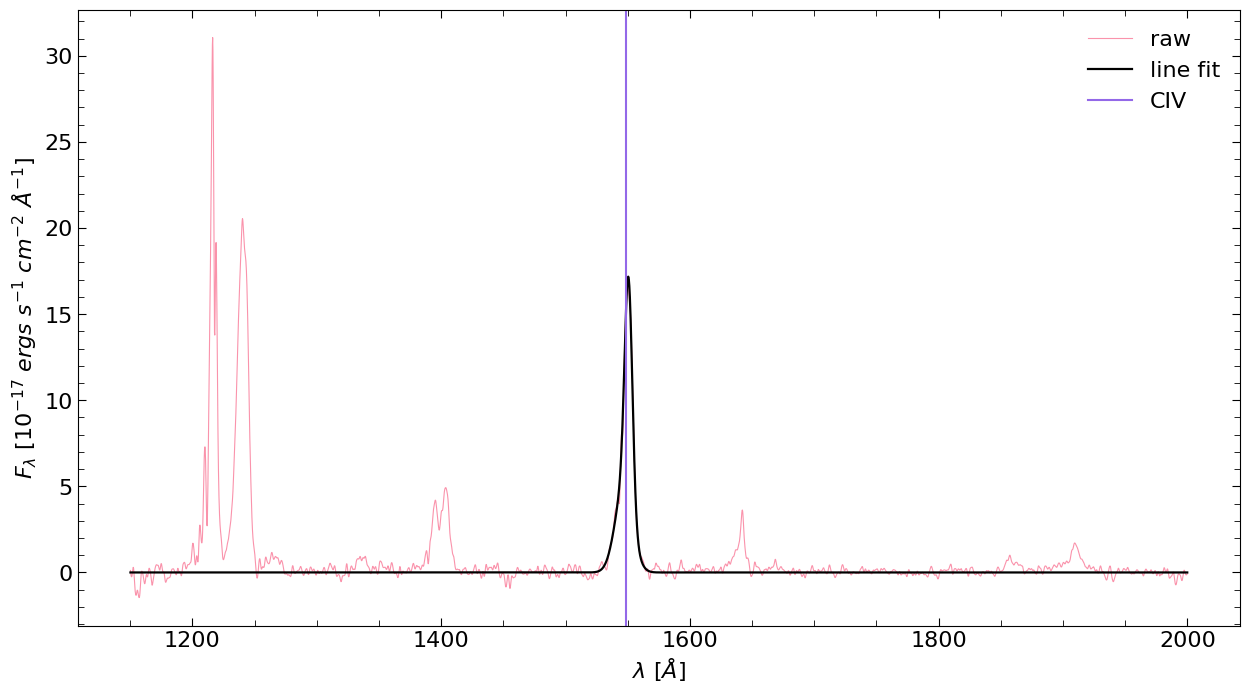


                SDSS: 233636.99+065231.0, DESI: 39627959455190480
                FWHM: 1691.932 vs 1483.559 (Hamann)
                REW: 189.979 vs 128.271 (Hamann)
                kt80: 0.294 vs 0.258 (Hamann)
                flux: 185.599 vs 215.999 (DESI)
    
---------------------------------------
---------------------------------------


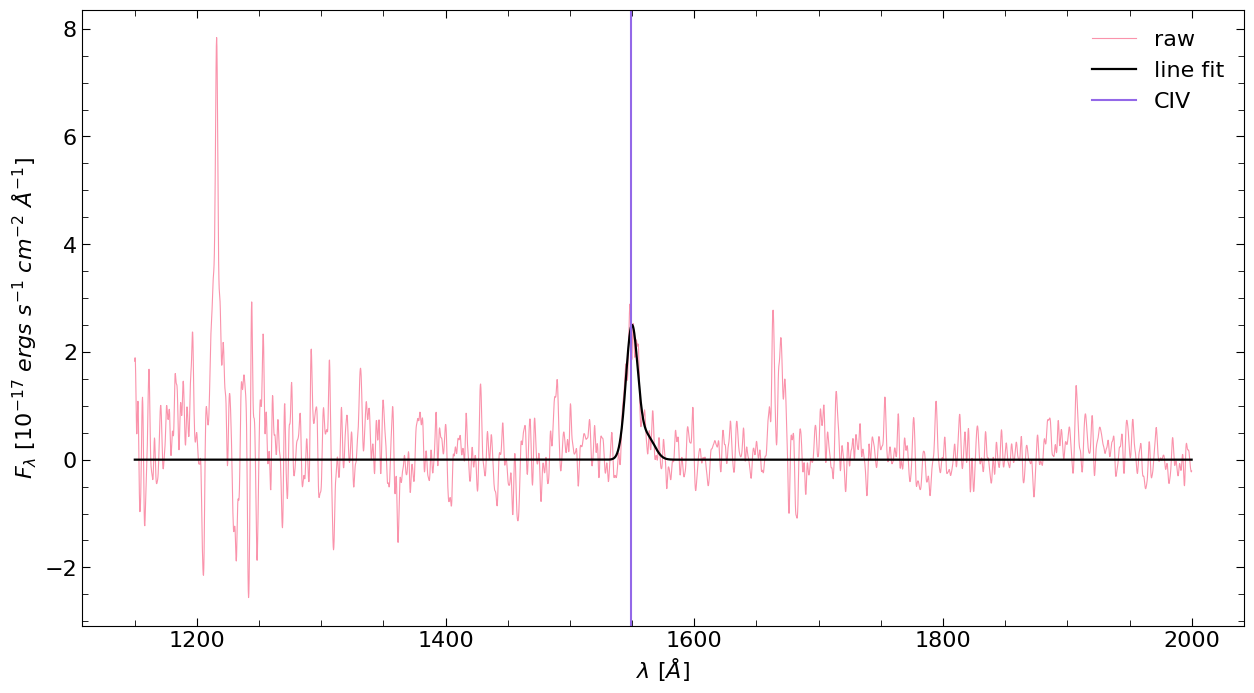


                SDSS: 091508.45+561316.0, DESI: 39633338616512873
                FWHM: 2317.045 vs 2867.477 (Hamann)
                REW: 96.702 vs 225.875 (Hamann)
                kt80: 0.319 vs 0.355 (Hamann)
                flux: 34.577 vs 44.154 (DESI)
    
---------------------------------------
---------------------------------------


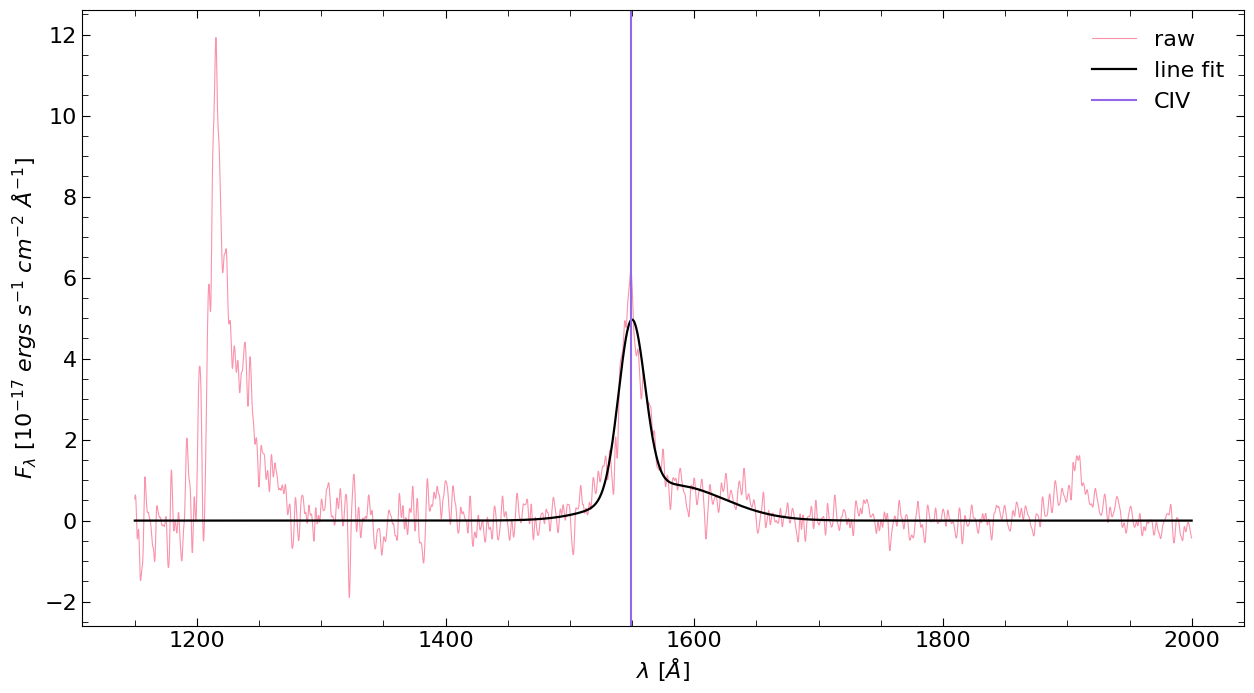


                SDSS: 082649.30+163945.2, DESI: 39628186186682006
                FWHM: 5365.037 vs 5633.199 (Hamann)
                REW: 137.564 vs 204.888 (Hamann)
                kt80: 0.308 vs 0.33 (Hamann)
                flux: 208.559 vs 182.182 (DESI)
    
---------------------------------------
---------------------------------------


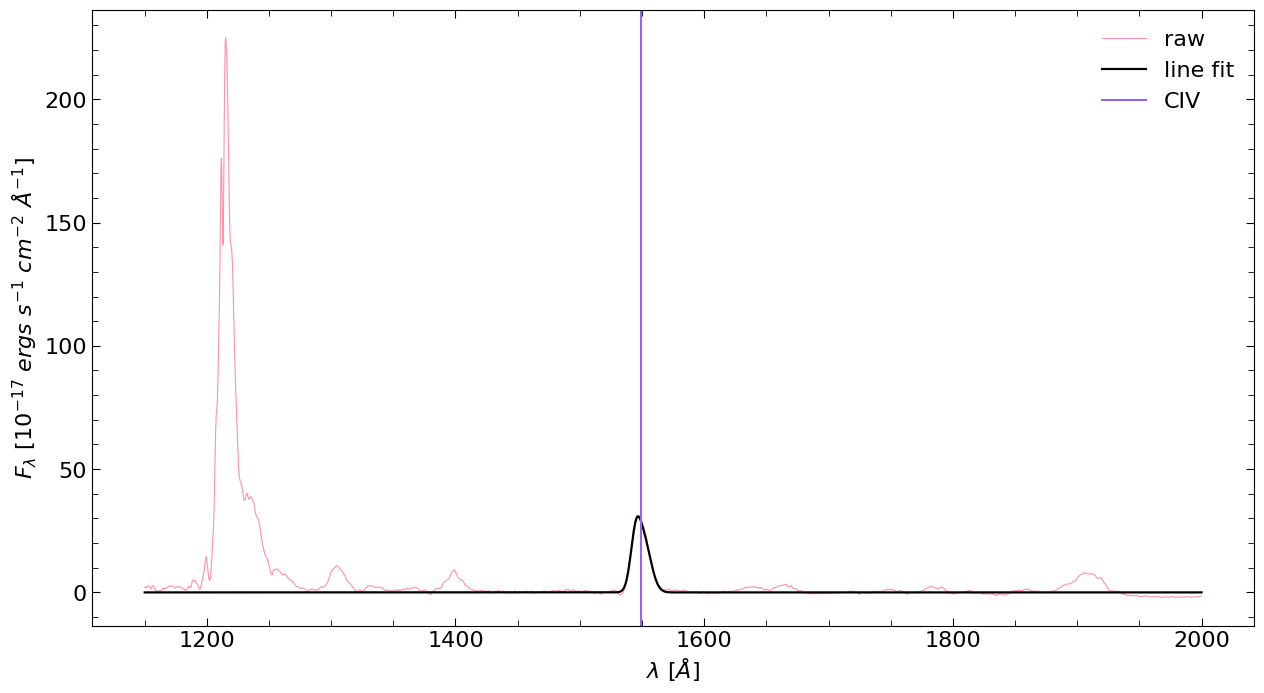


                SDSS: 083448.48+015921.1, DESI: 39627835203130381
                FWHM: 2917.331 vs 2863.092 (Hamann)
                REW: 275.934 vs 209.44 (Hamann)
                kt80: 0.372 vs 0.365 (Hamann)
                flux: 482.445 vs 549.36 (DESI)
    
---------------------------------------
---------------------------------------


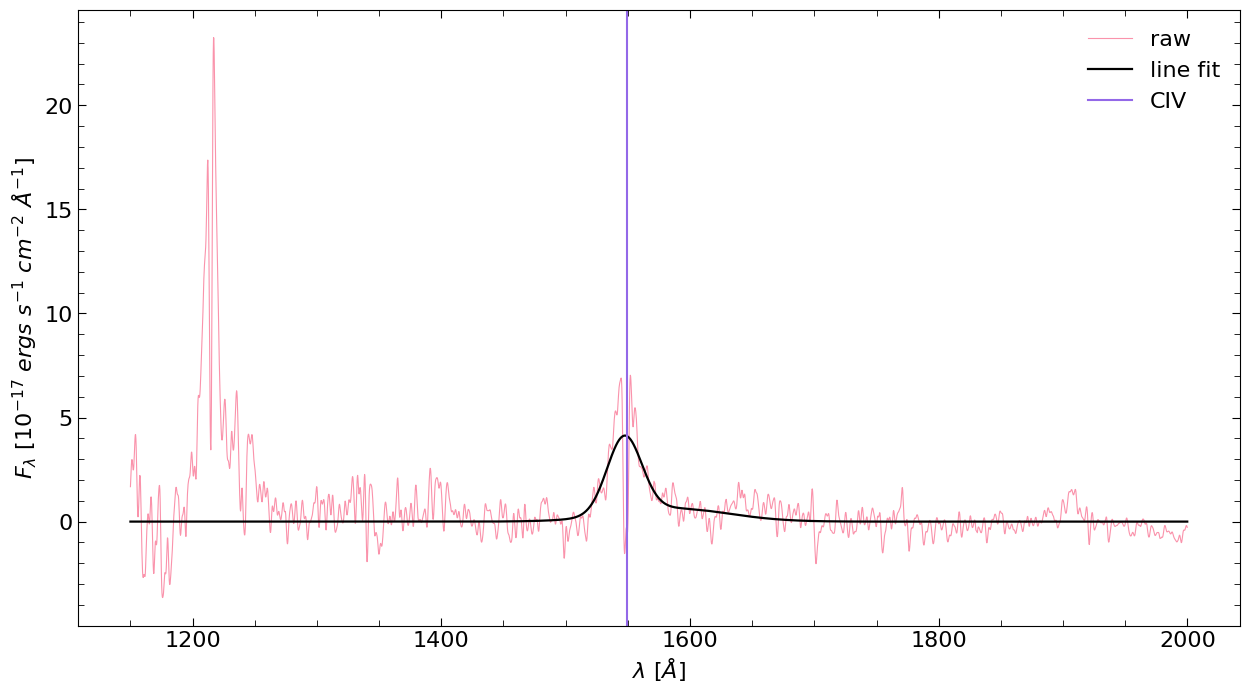


                SDSS: 135608.32+073017.2, DESI: 39627969034979107
                FWHM: 6879.58 vs 2043.349 (Hamann)
                REW: 80.062 vs 109.67 (Hamann)
                kt80: 0.329 vs 0.372 (Hamann)
                flux: 197.52 vs 2.869 (DESI)
    
---------------------------------------
---------------------------------------


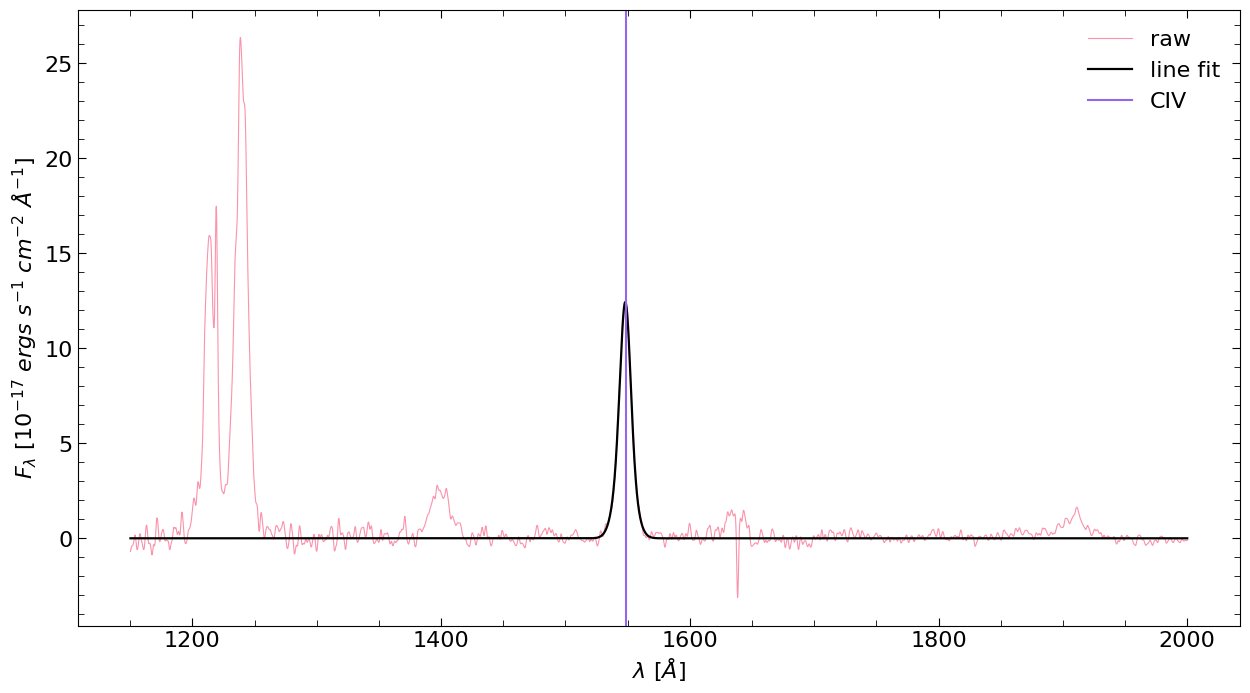


                SDSS: 131722.85+322207.5, DESI: 39628527628192559
                FWHM: 2226.937 vs 2310.771 (Hamann)
                REW: 177.442 vs 159.85 (Hamann)
                kt80: 0.34 vs 0.36 (Hamann)
                flux: 160.997 vs 169.607 (DESI)
    
---------------------------------------
---------------------------------------


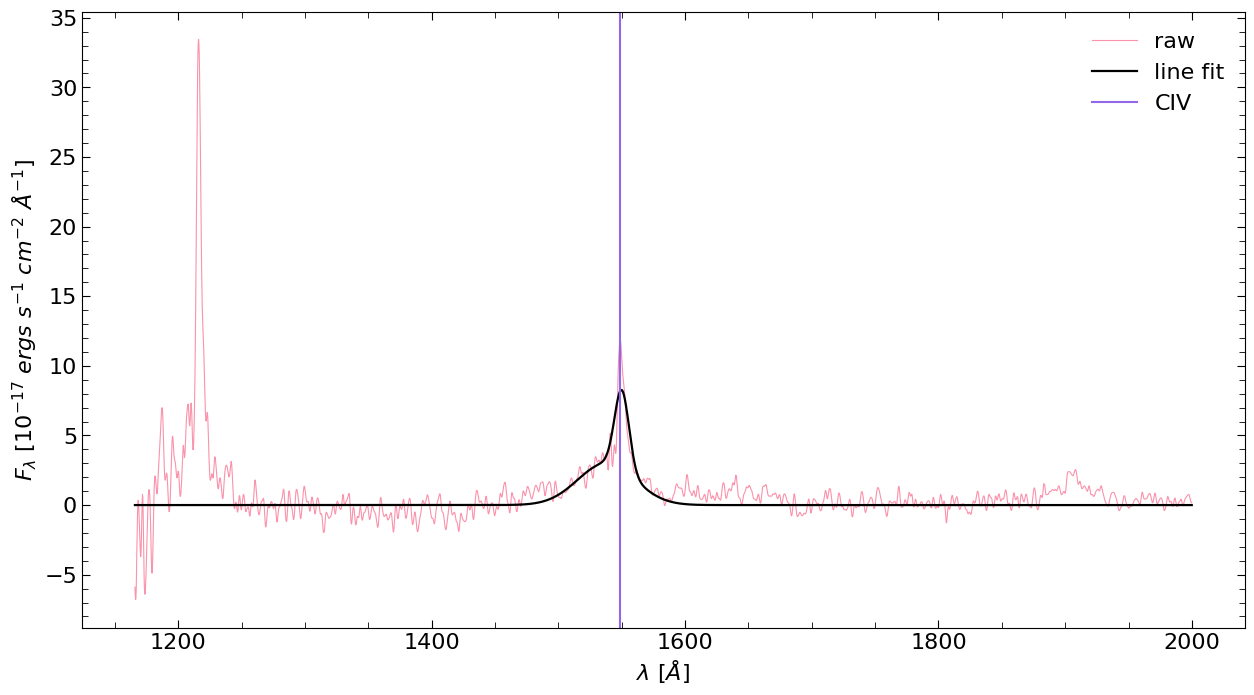


                SDSS: 082536.31+200040.3, DESI: 39628260832707100
                FWHM: 3496.576 vs 3265.175 (Hamann)
                REW: 130.33 vs 210.805 (Hamann)
                kt80: 0.18 vs 0.171 (Hamann)
                flux: 277.237 vs 98.607 (DESI)
    
---------------------------------------
---------------------------------------


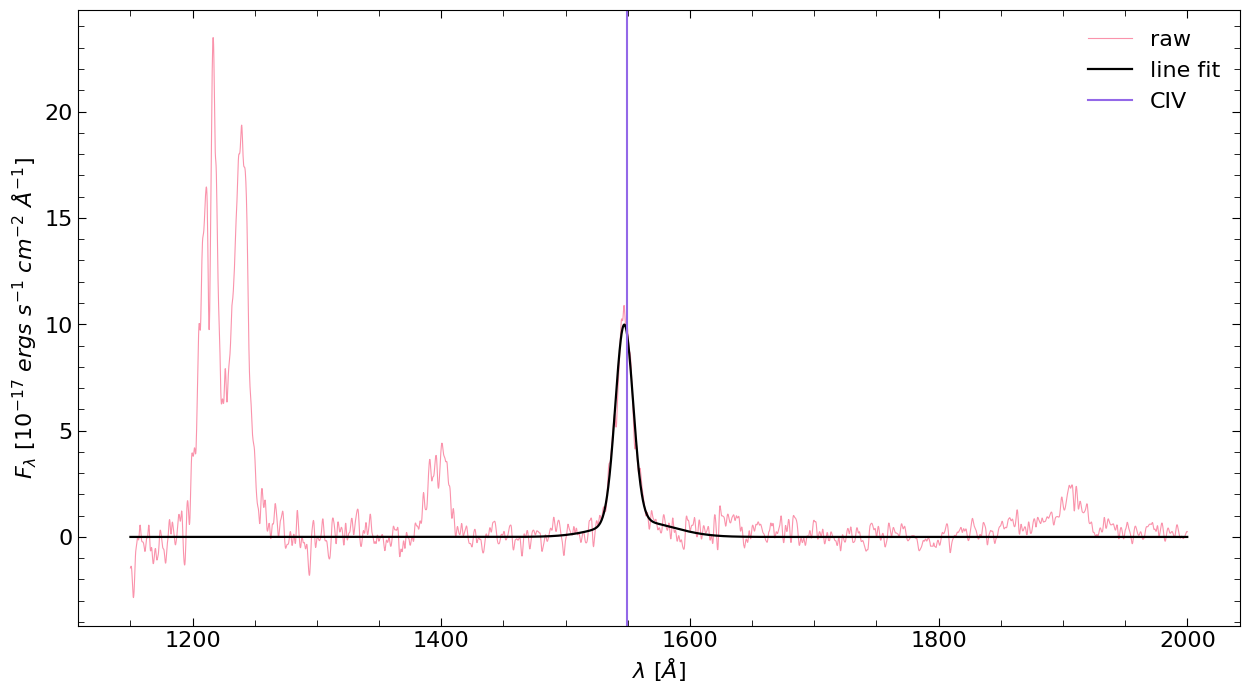


                SDSS: 130936.14+560111.3, DESI: 39633335785357580
                FWHM: 3404.701 vs 3629.606 (Hamann)
                REW: 218.626 vs 160.873 (Hamann)
                kt80: 0.355 vs 0.361 (Hamann)
                flux: 217.774 vs 224.631 (DESI)
    
---------------------------------------
---------------------------------------


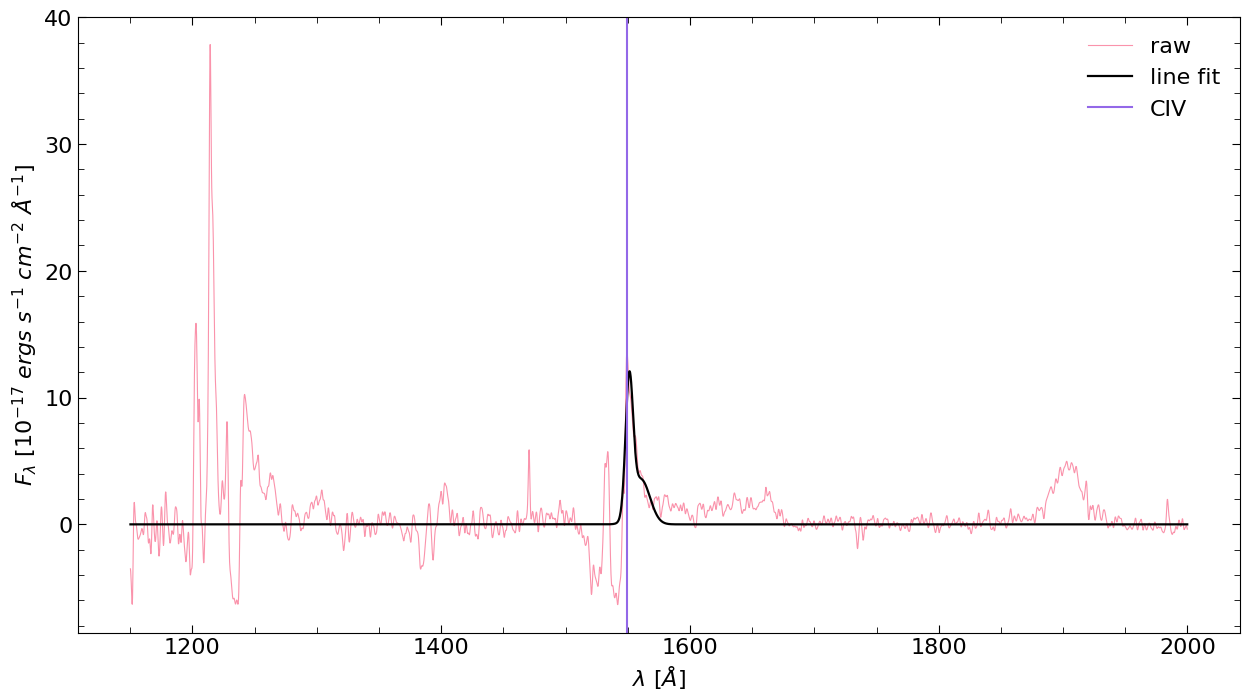


                SDSS: 170558.64+273624.7, DESI: 39628428831360551
                FWHM: 1572.777 vs 1300.839 (Hamann)
                REW: 30.498 vs 157.472 (Hamann)
                kt80: 0.208 vs 0.359 (Hamann)
                flux: 125.9 vs 127.458 (DESI)
    
---------------------------------------
---------------------------------------


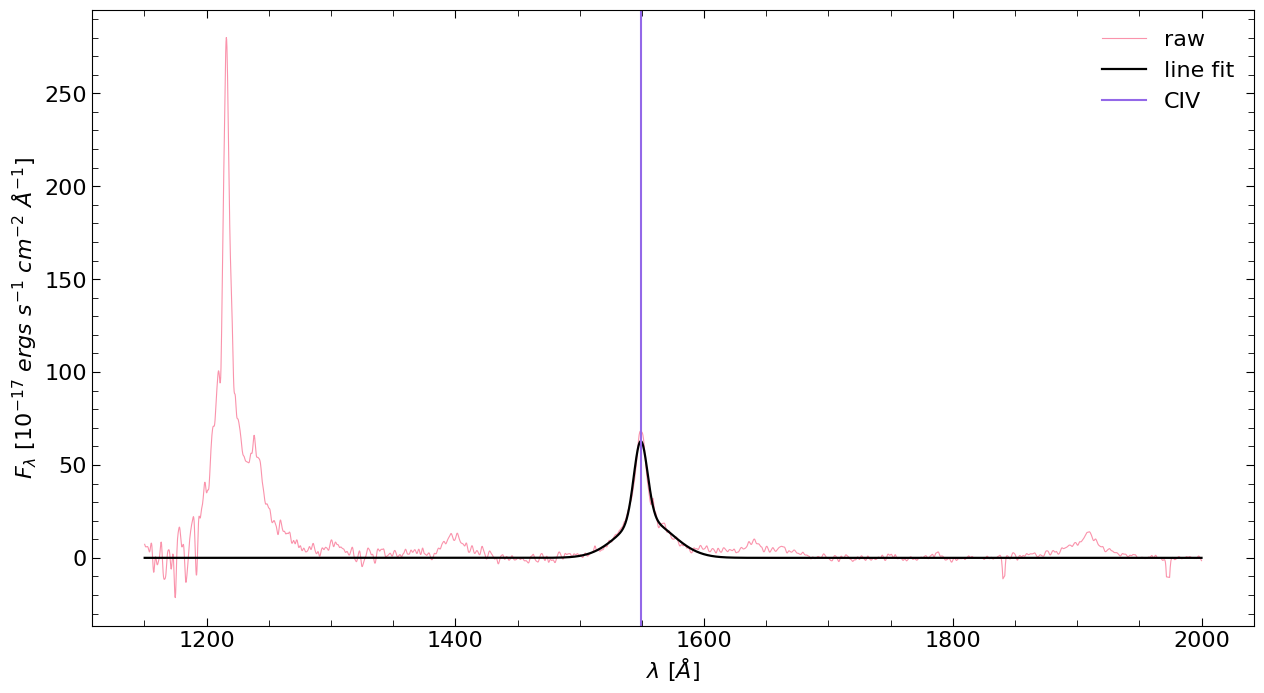


                SDSS: 223754.52+065026.6, DESI: 39627953214063409
                FWHM: 3274.047 vs 1390.575 (Hamann)
                REW: 58.343 vs 140.677 (Hamann)
                kt80: 0.207 vs 0.356 (Hamann)
                flux: 1720.296 vs 2147.366 (DESI)
    
---------------------------------------
---------------------------------------


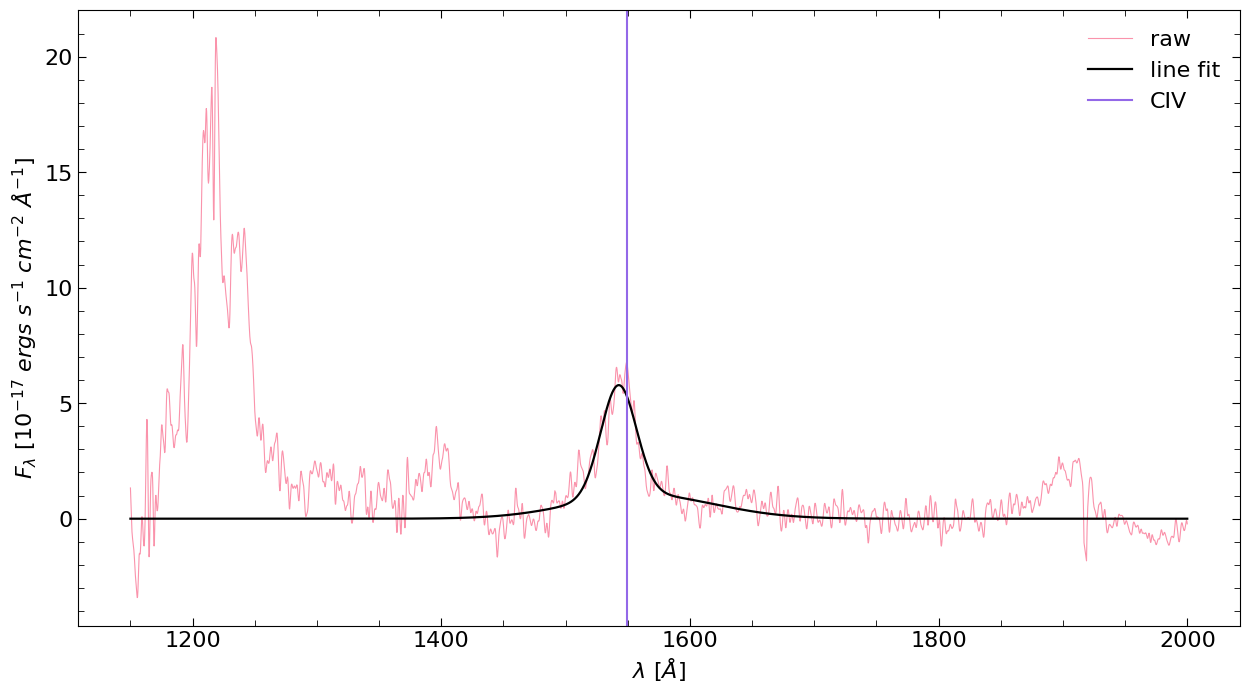


                SDSS: 000610.67+121501.2, DESI: 39628078766358575
                FWHM: 7355.246 vs 4540.061 (Hamann)
                REW: 43.527 vs 106.997 (Hamann)
                kt80: 0.31 vs 0.372 (Hamann)
                flux: 308.531 vs 327.141 (DESI)
    
---------------------------------------
---------------------------------------


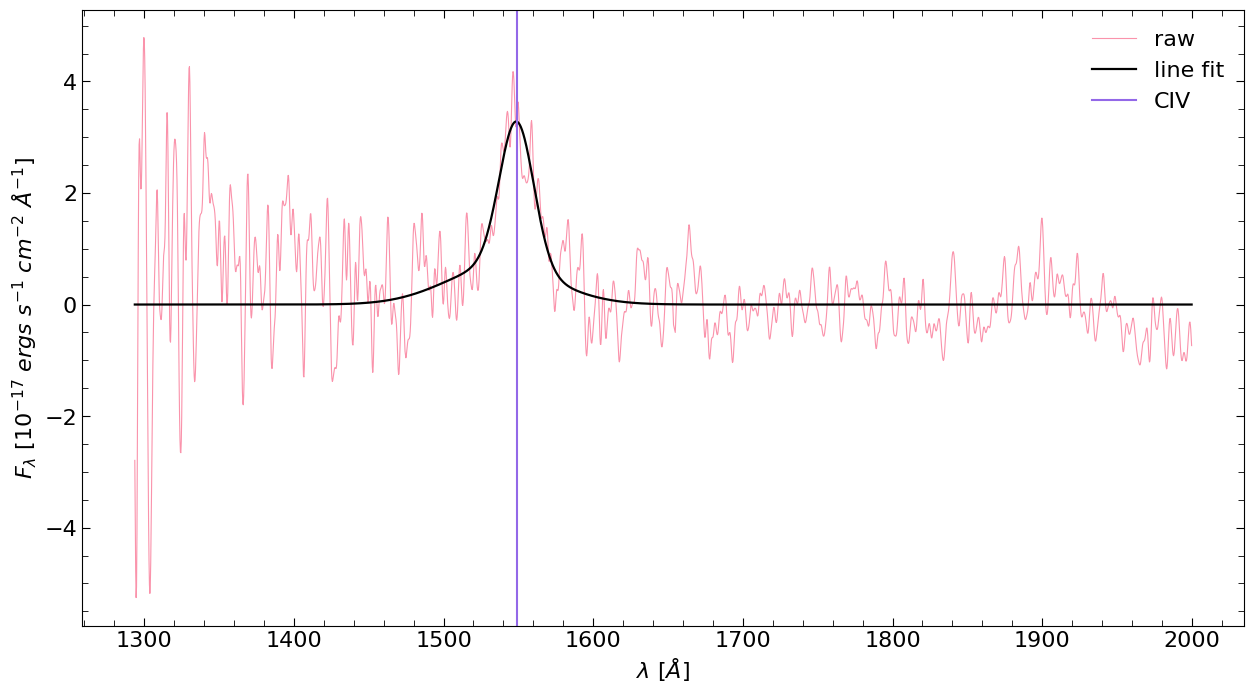


                SDSS: 005044.95-021217.6, DESI: 39627730584601174
                FWHM: 6028.113 vs 4343.058 (Hamann)
                REW: 218.481 vs 147.225 (Hamann)
                kt80: 0.306 vs 0.193 (Hamann)
                flux: 134.206 vs 140.904 (DESI)
    
---------------------------------------
---------------------------------------


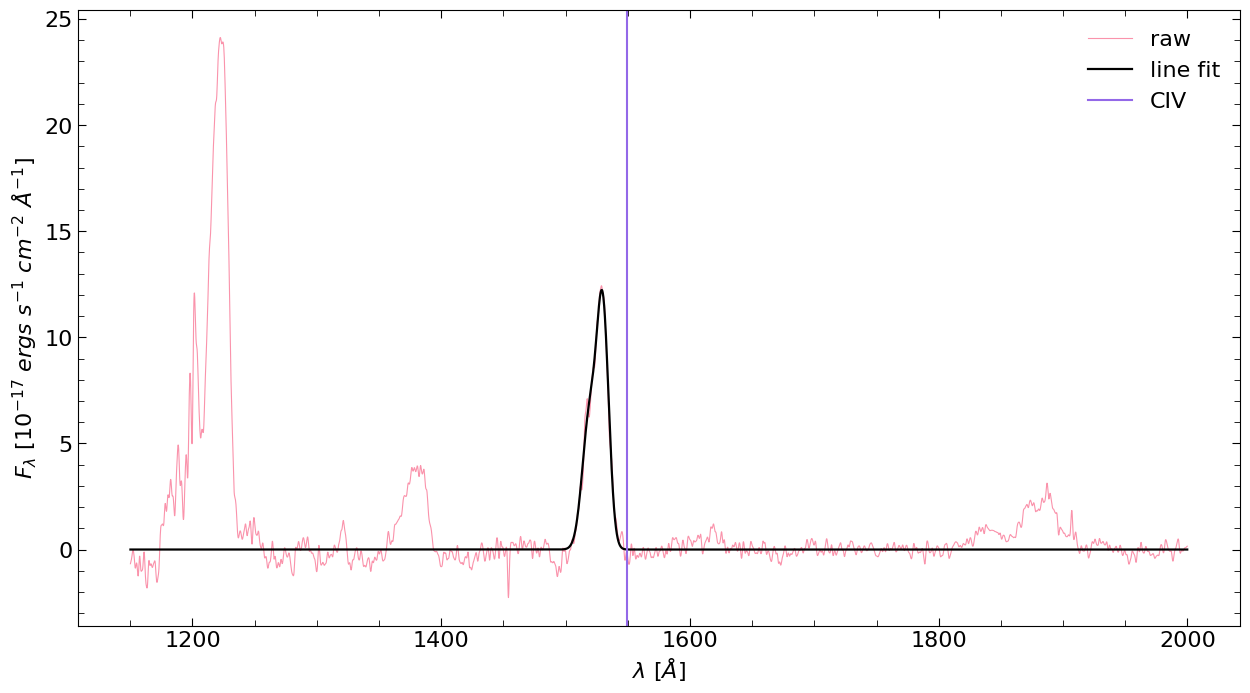


                SDSS: 002400.25+245031.9, DESI: 39628365275075274
                FWHM: 3500.679 vs 3523.282 (Hamann)
                REW: 148.8 vs 143.69 (Hamann)
                kt80: 0.304 vs 0.372 (Hamann)
                flux: 222.117 vs 25.127 (DESI)
    
---------------------------------------
---------------------------------------


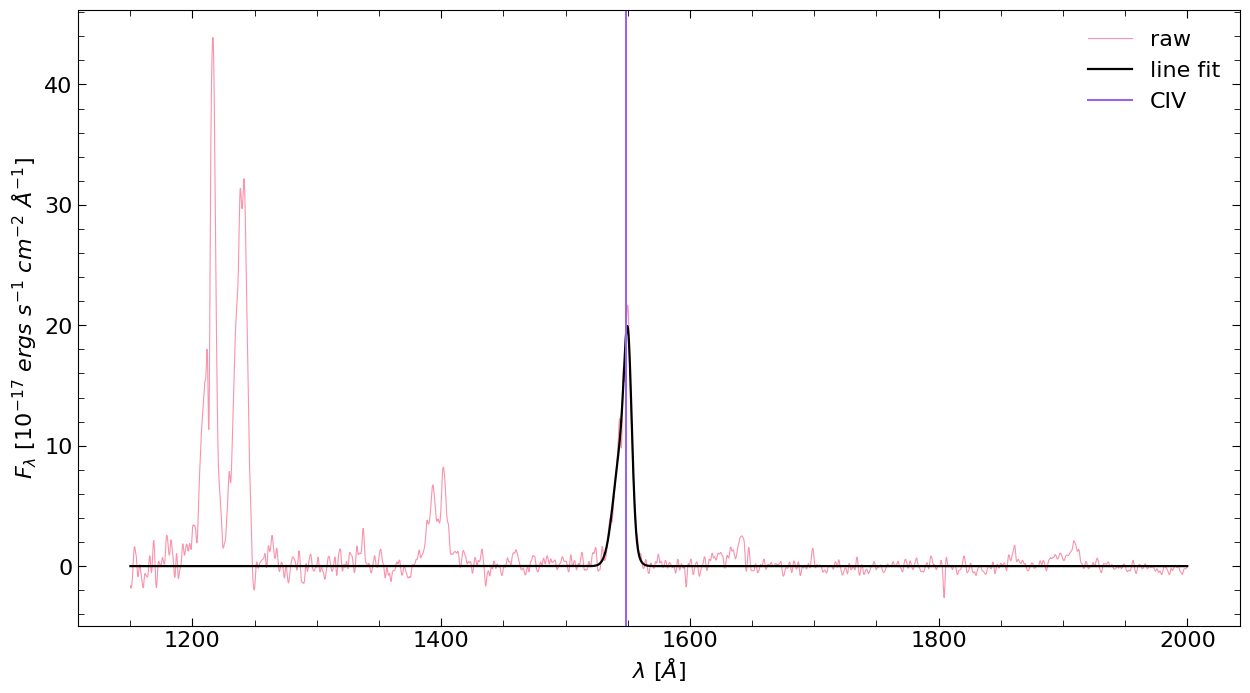


                SDSS: 134026.99+083427.2, DESI: 39627992917347231
                FWHM: 2068.774 vs 2075.846 (Hamann)
                REW: 313.54 vs 357.973 (Hamann)
                kt80: 0.266 vs 0.345 (Hamann)
                flux: 249.339 vs 251.394 (DESI)
    
---------------------------------------
---------------------------------------


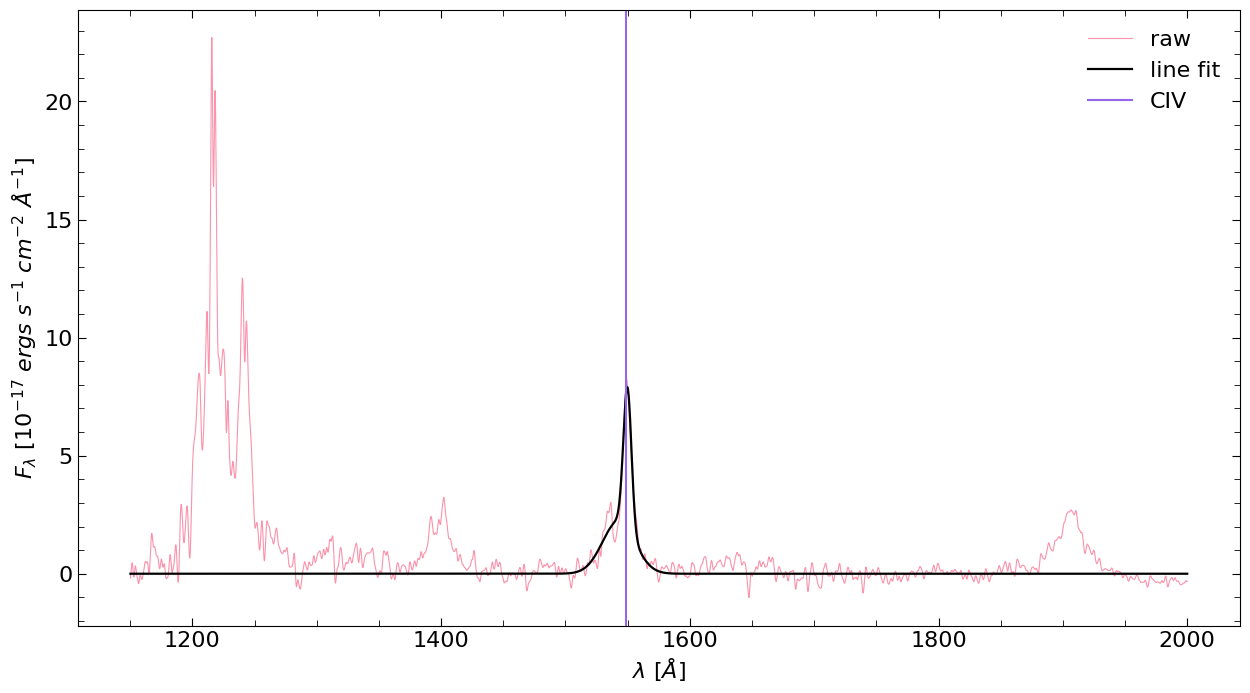


                SDSS: 134001.90+322155.9, DESI: 39628527707885249
                FWHM: 1827.222 vs 1822.703 (Hamann)
                REW: 128.737 vs 130.709 (Hamann)
                kt80: 0.199 vs 0.207 (Hamann)
                flux: 122.406 vs 92.811 (DESI)
    
---------------------------------------
---------------------------------------


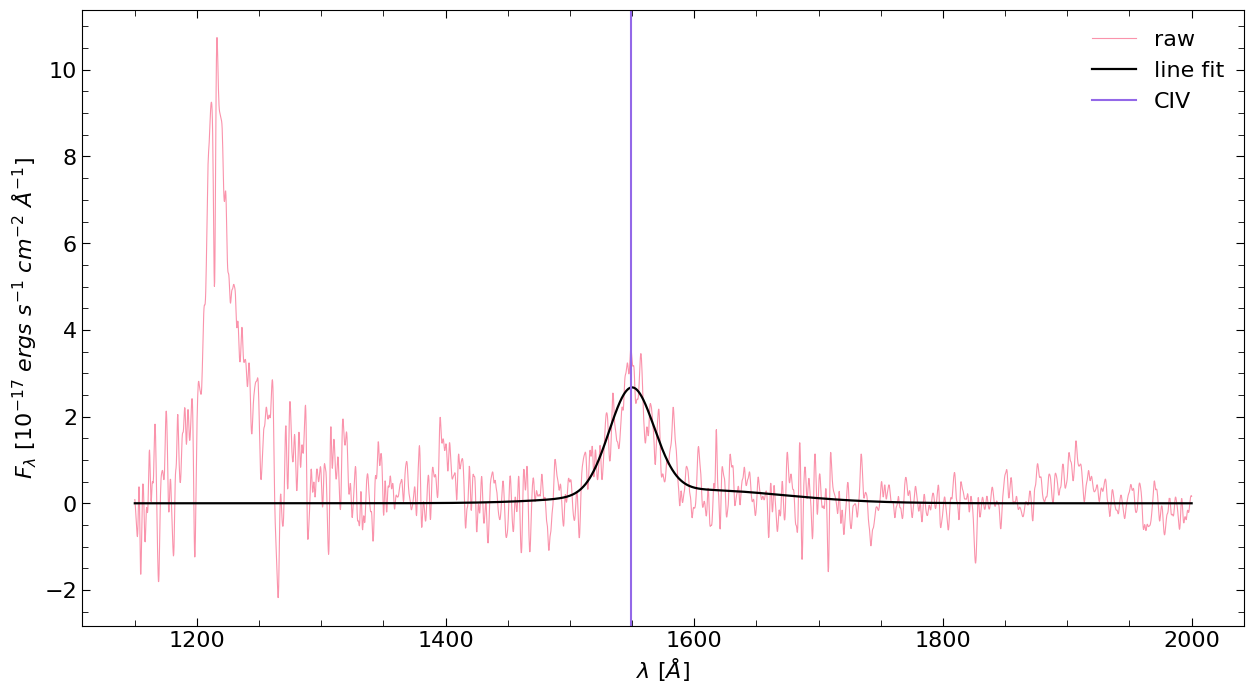


                SDSS: 222421.63+174041.2, DESI: 39628212648546243
                FWHM: 8800.518 vs 2748.994 (Hamann)
                REW: 78.354 vs 110.457 (Hamann)
                kt80: 0.343 vs 0.191 (Hamann)
                flux: 151.295 vs 103.645 (DESI)
    
---------------------------------------
---------------------------------------


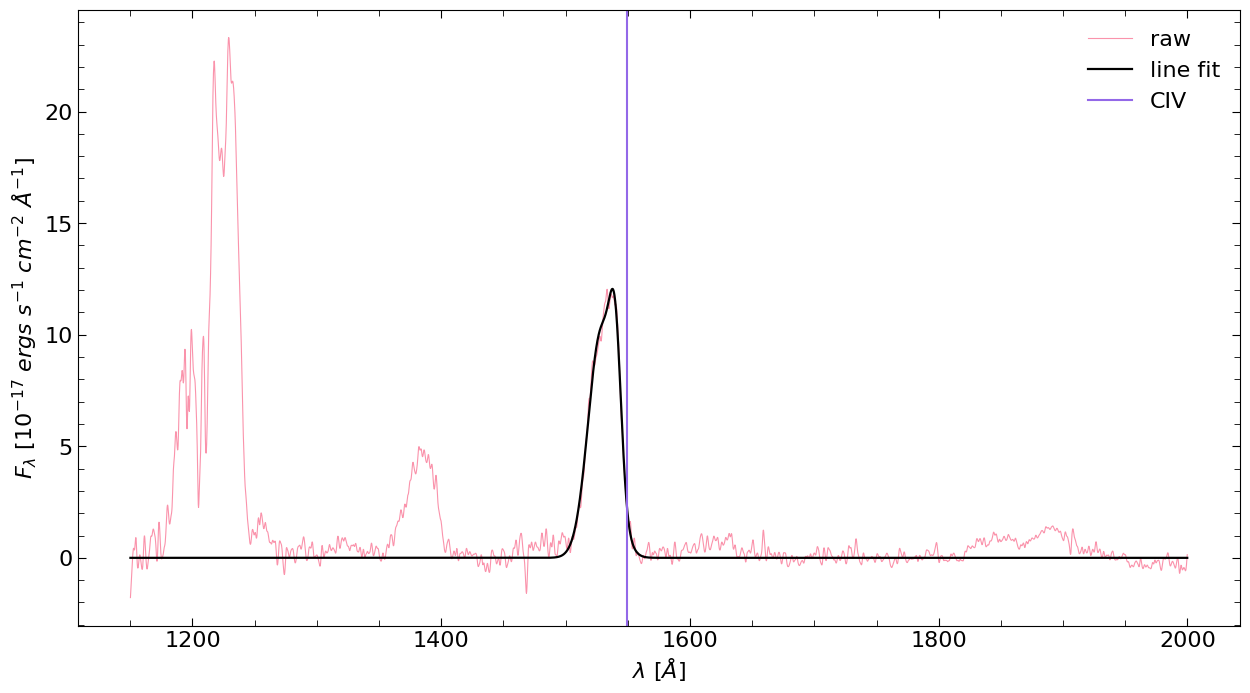


                SDSS: 104611.50+024351.6, DESI: 39627853876167561
                FWHM: 5282.09 vs 4854.269 (Hamann)
                REW: 220.836 vs 217.582 (Hamann)
                kt80: 0.442 vs 0.354 (Hamann)
                flux: 334.296 vs 255.654 (DESI)
    
---------------------------------------
---------------------------------------


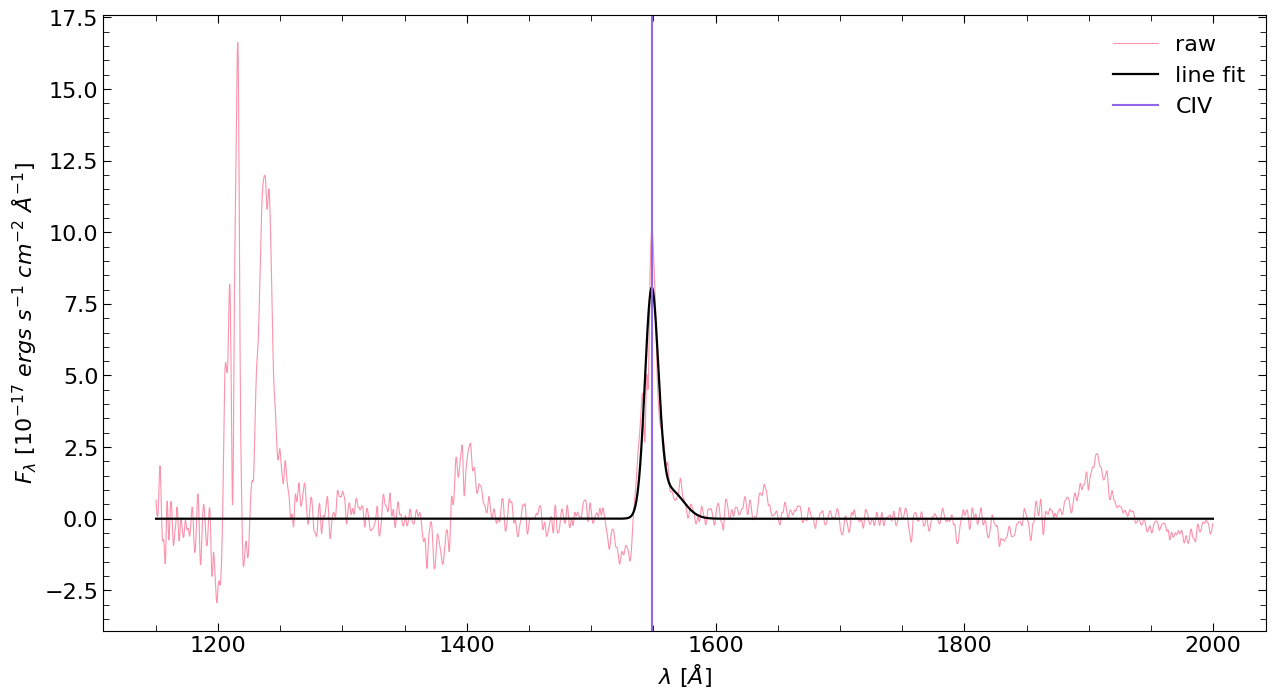


                SDSS: 093506.96-024137.7, DESI: 39627720702820887
                FWHM: 2572.671 vs 2404.04 (Hamann)
                REW: 85.594 vs 119.496 (Hamann)
                kt80: 0.344 vs 0.249 (Hamann)
                flux: 131.86 vs 147.833 (DESI)
    
---------------------------------------
---------------------------------------


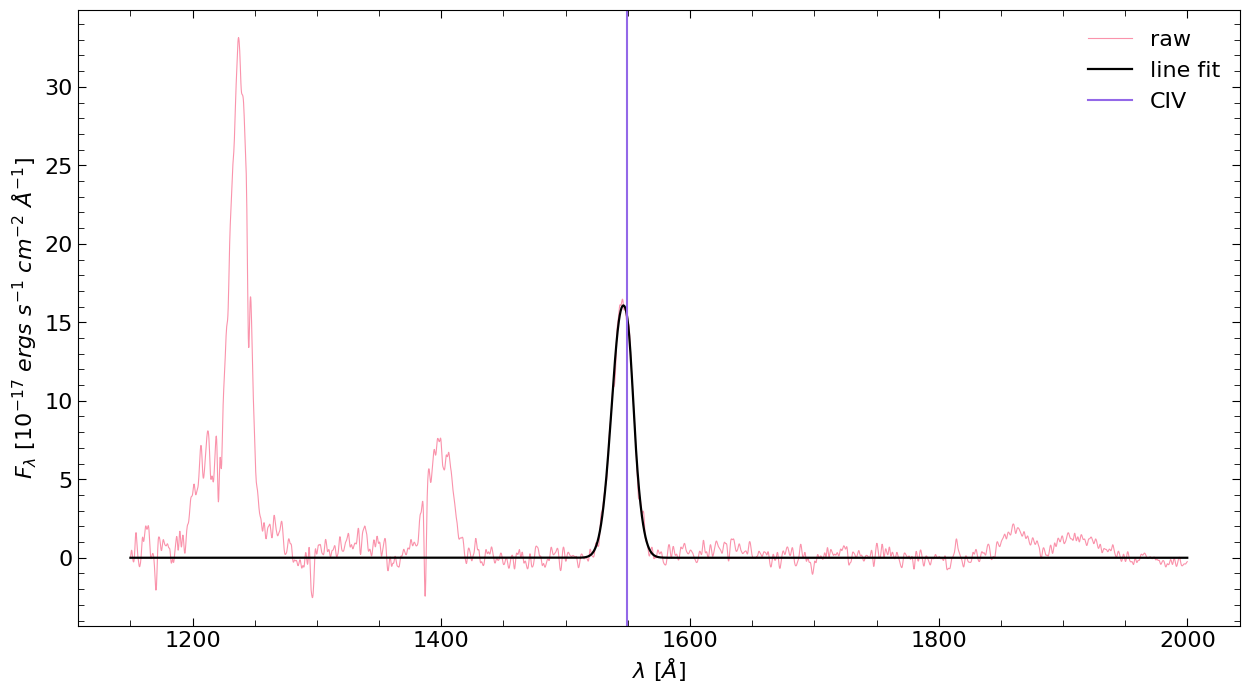


                SDSS: 232326.17-010033.1, DESI: 39627766454292268
                FWHM: 3897.765 vs 3989.27 (Hamann)
                REW: 326.433 vs 255.993 (Hamann)
                kt80: 0.407 vs 0.371 (Hamann)
                flux: 345.846 vs 374.365 (DESI)
    
---------------------------------------
---------------------------------------


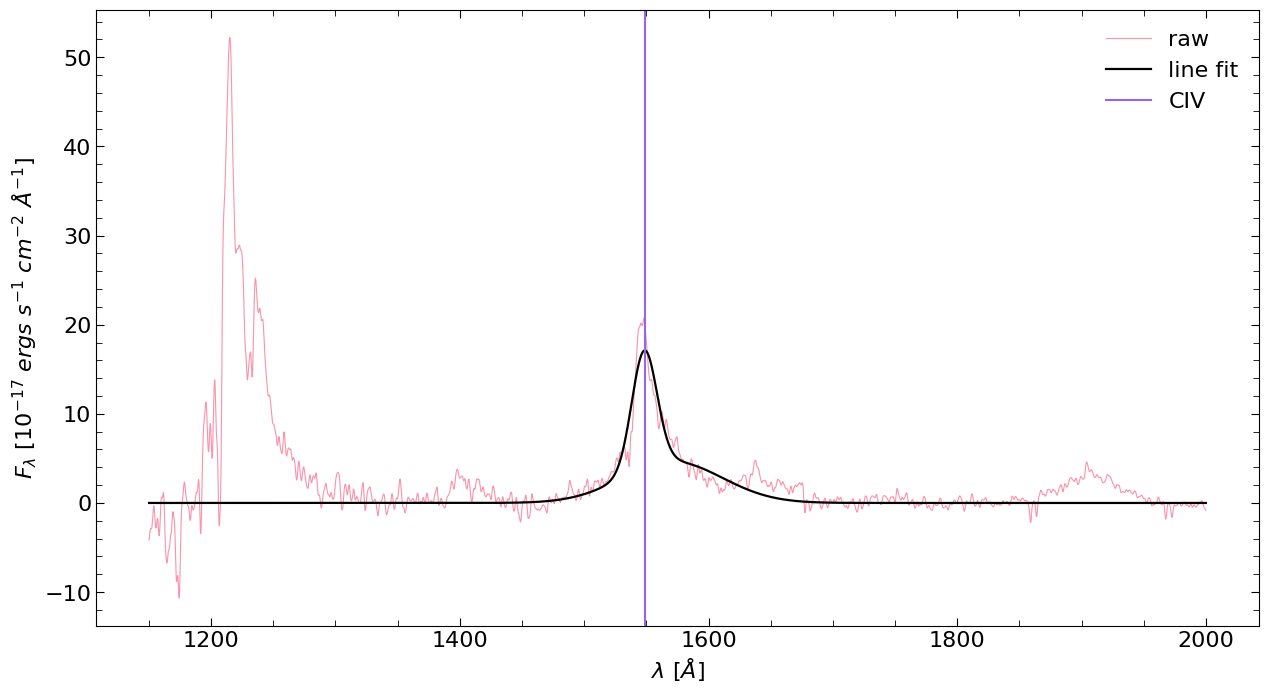


                SDSS: 102541.78+245424.2, DESI: 39628367573551586
                FWHM: 5602.919 vs 5324.386 (Hamann)
                REW: 65.754 vs 114.538 (Hamann)
                kt80: 0.202 vs 0.365 (Hamann)
                flux: 824.159 vs 737.437 (DESI)
    
---------------------------------------
---------------------------------------


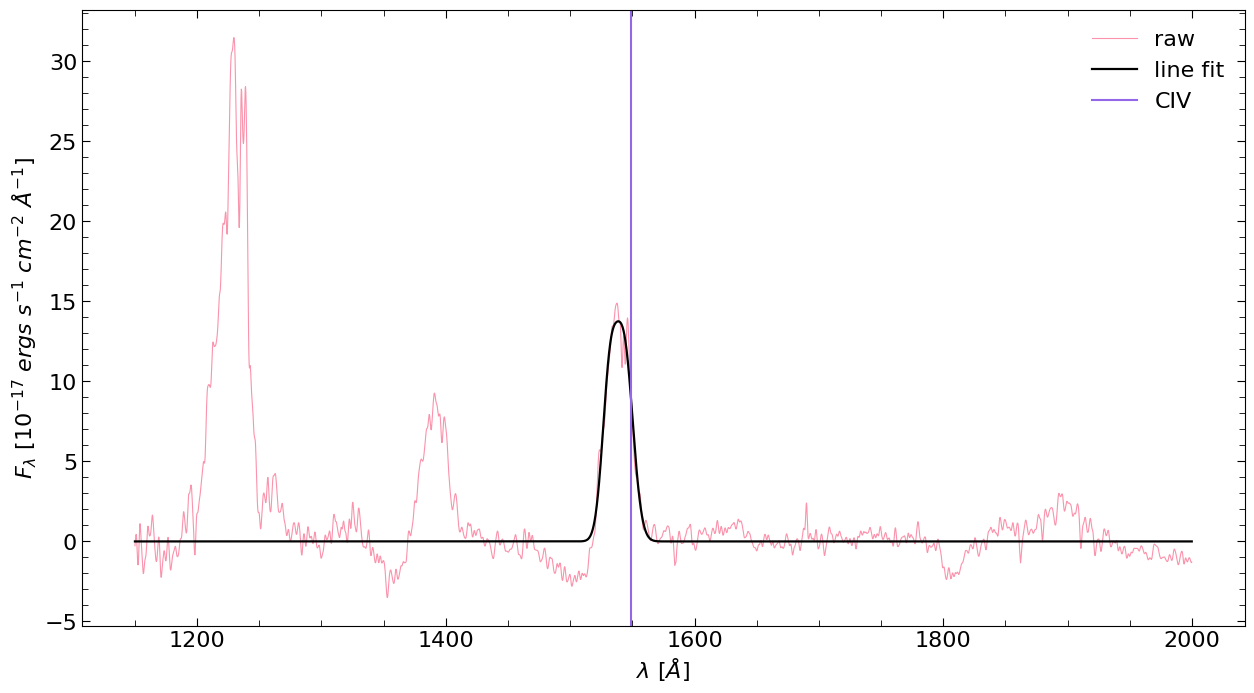


                SDSS: 103146.53+290324.1, DESI: 39628459336535305
                FWHM: 4755.603 vs 4363.774 (Hamann)
                REW: 82.493 vs 120.767 (Hamann)
                kt80: 0.488 vs 0.372 (Hamann)
                flux: 343.821 vs 321.487 (DESI)
    
---------------------------------------
---------------------------------------


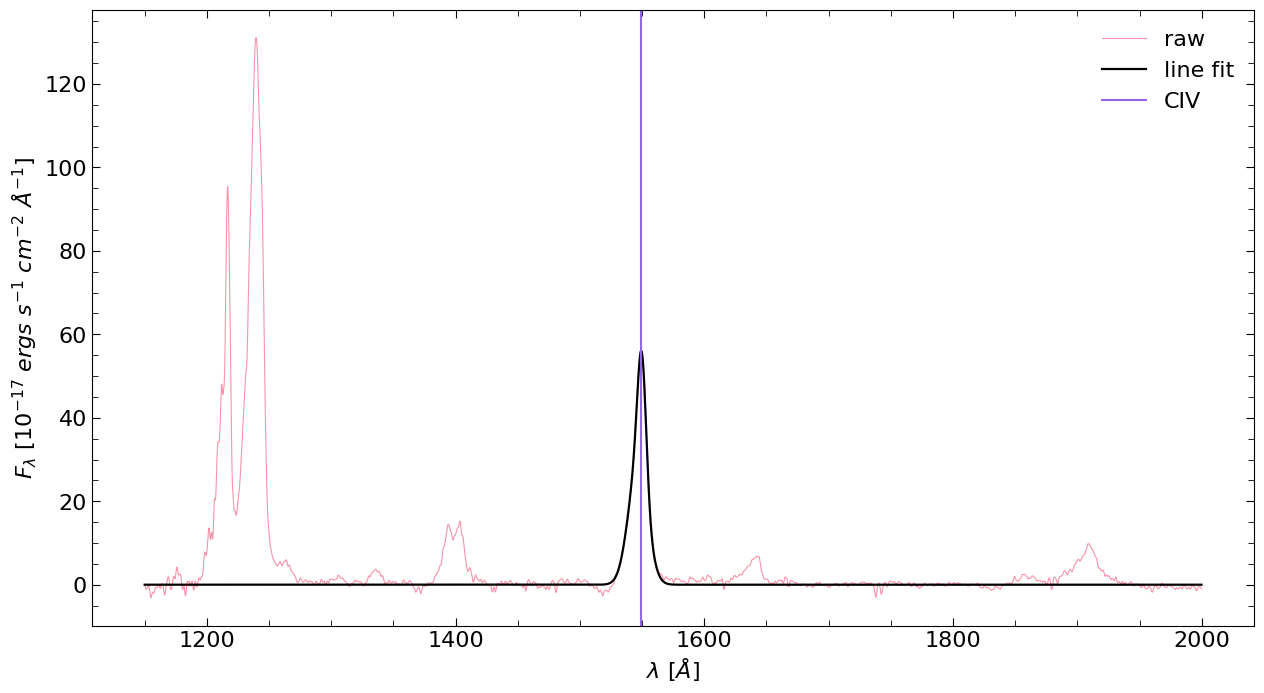


                SDSS: 165202.64+172852.3, DESI: 39628205555974657
                FWHM: 2316.015 vs 2403.322 (Hamann)
                REW: 191.799 vs 124.521 (Hamann)
                kt80: 0.283 vs 0.329 (Hamann)
                flux: 800.169 vs 905.182 (DESI)
    
---------------------------------------
---------------------------------------


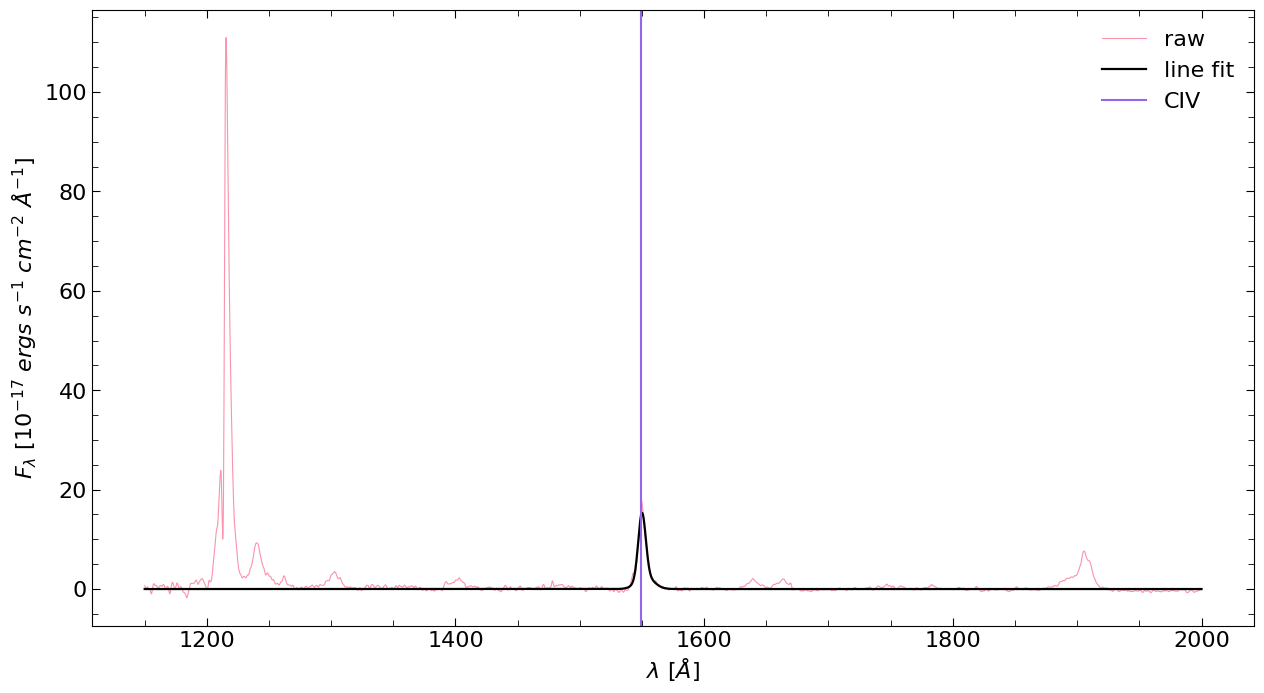


                SDSS: 122000.68+064045.3, DESI: 39627950634570587
                FWHM: 1497.177 vs 1047.131 (Hamann)
                REW: 137.022 vs 112.877 (Hamann)
                kt80: 0.342 vs 0.151 (Hamann)
                flux: 139.864 vs 137.558 (DESI)
    
---------------------------------------
---------------------------------------


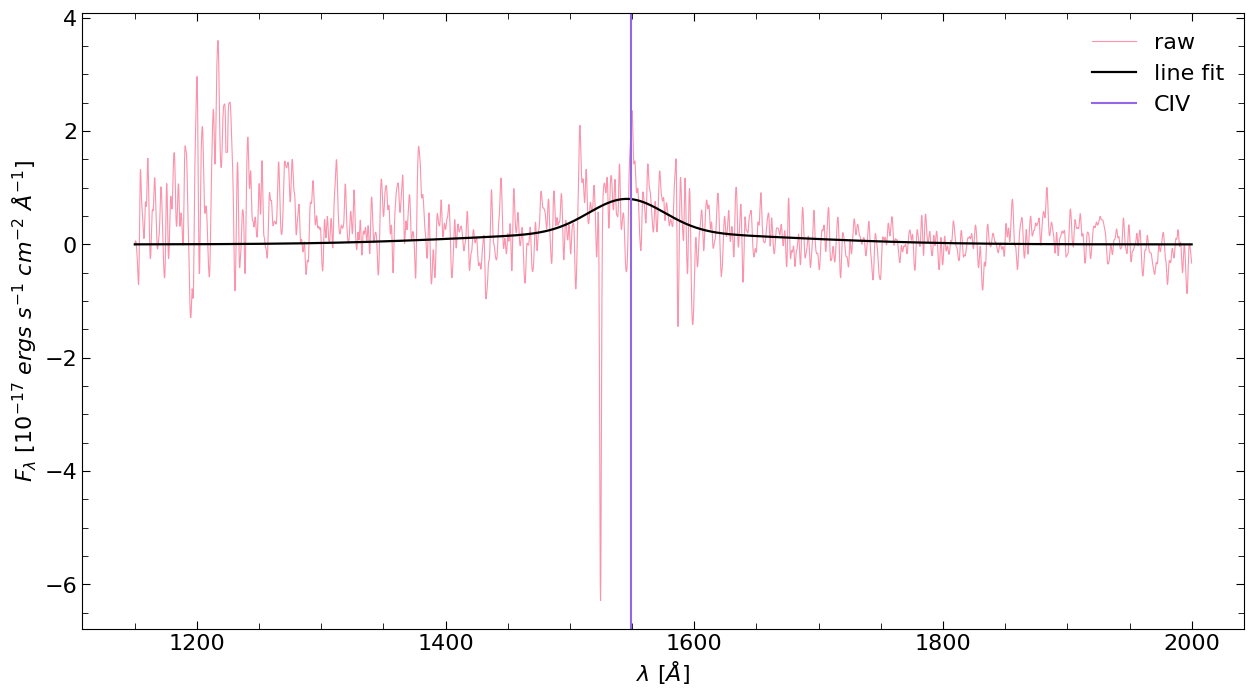


                SDSS: 084447.66+462338.7, DESI: 39633191010567641
                FWHM: 16951.497 vs 1656.003 (Hamann)
                REW: 161.863 vs 160.601 (Hamann)
                kt80: 0.258 vs 0.346 (Hamann)
                flux: 73.998 vs 50.4 (DESI)
    
---------------------------------------
---------------------------------------


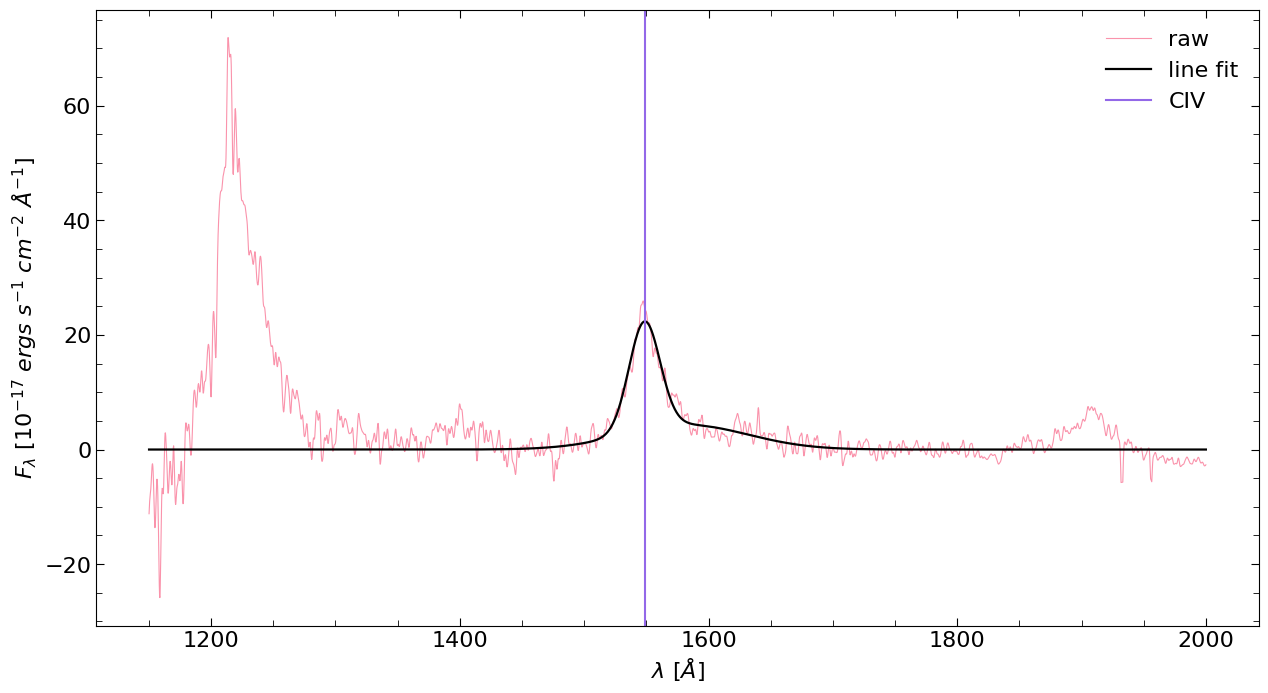


                SDSS: 125019.46+630638.6, DESI: 2782190211432454
                FWHM: 6429.856 vs 1881.225 (Hamann)
                REW: 44.278 vs 242.256 (Hamann)
                kt80: 0.287 vs 0.341 (Hamann)
                flux: 1079.55 vs 1257.858 (DESI)
    
---------------------------------------
---------------------------------------


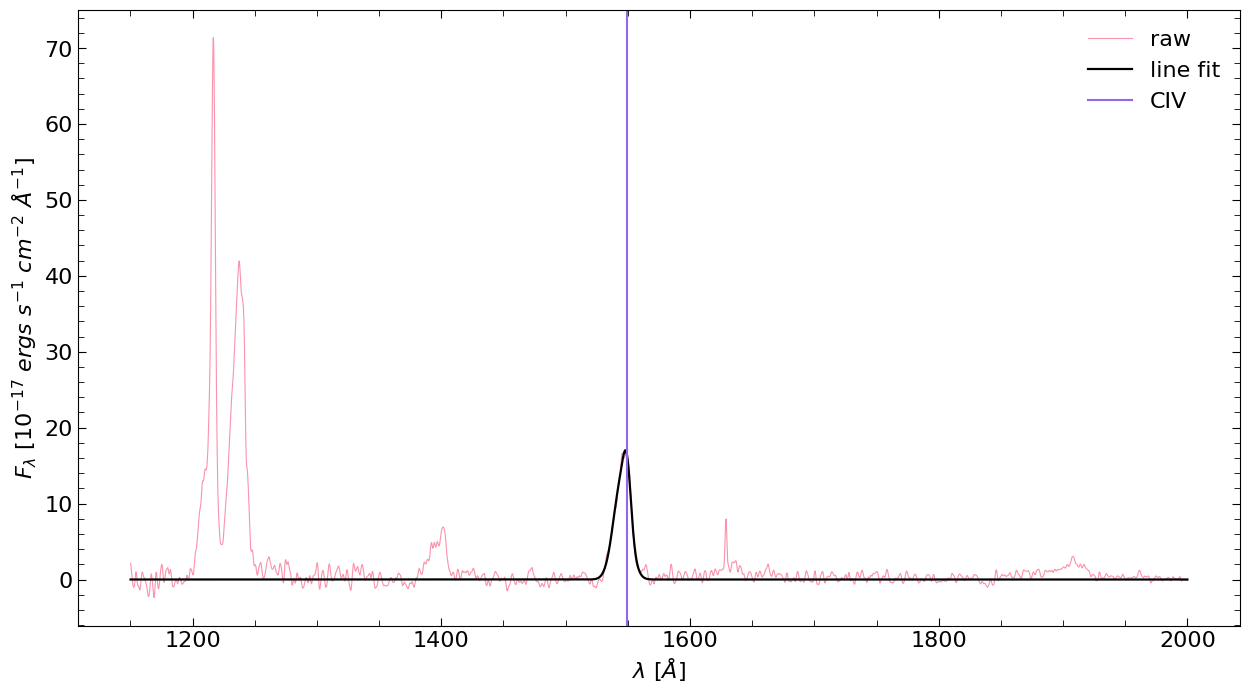


                SDSS: 121704.70+023417.1, DESI: 39627848218050974
                FWHM: 2760.147 vs 2603.968 (Hamann)
                REW: 246.748 vs 180.897 (Hamann)
                kt80: 0.341 vs 0.369 (Hamann)
                flux: 256.724 vs 281.832 (DESI)
    
---------------------------------------
---------------------------------------


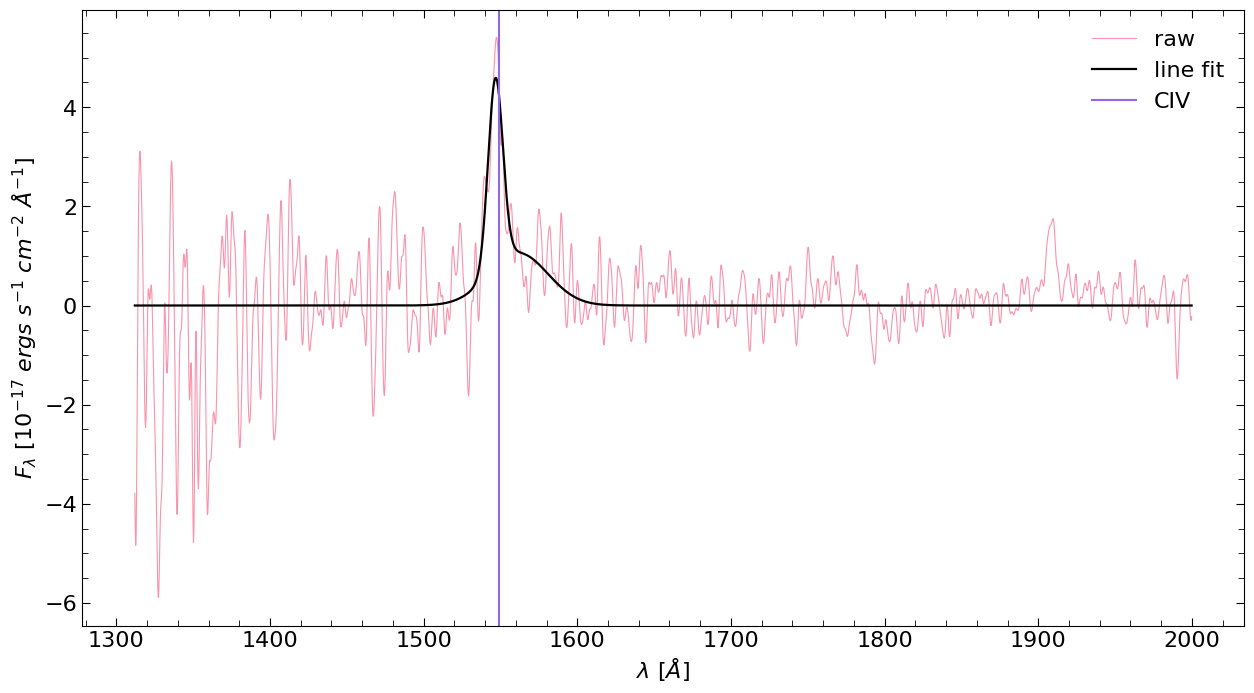


                SDSS: 111355.72+451452.6, DESI: 39633170341038247
                FWHM: 2524.129 vs 1243.226 (Hamann)
                REW: 123.148 vs 190.171 (Hamann)
                kt80: 0.204 vs 0.351 (Hamann)
                flux: 99.675 vs 111.87 (DESI)
    
---------------------------------------
---------------------------------------


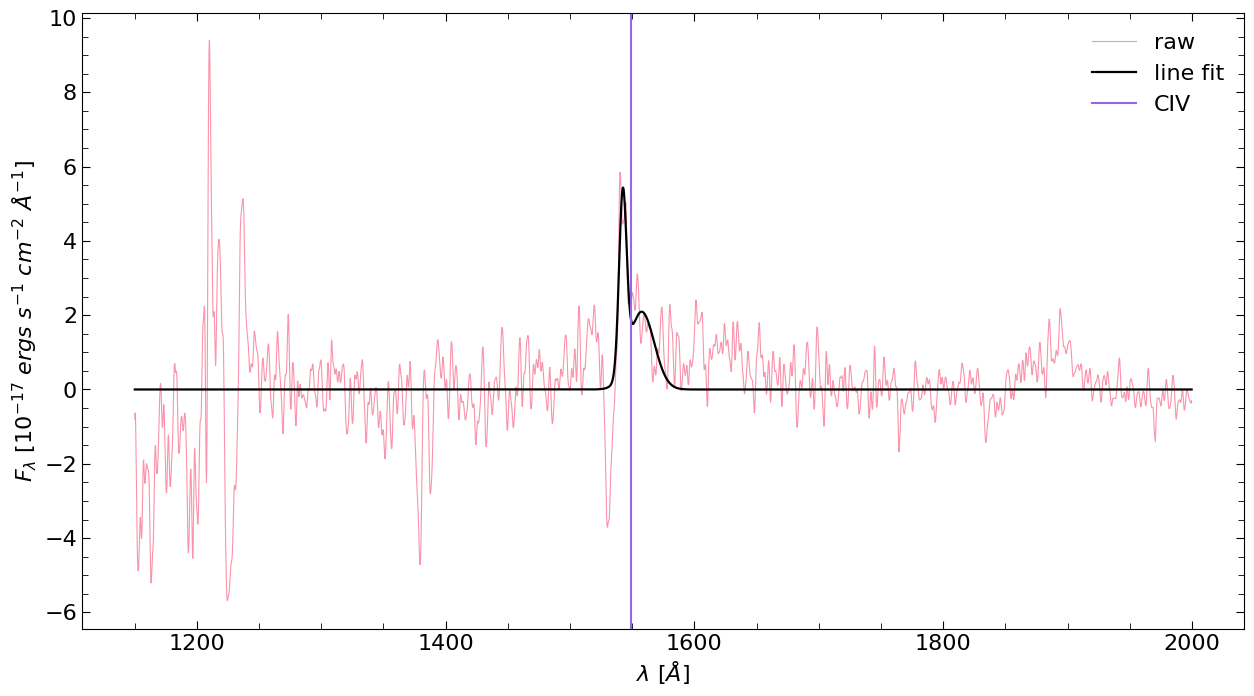


                SDSS: 093638.41+101930.3, DESI: 39628033660814172
                FWHM: 1567.97 vs 1271.195 (Hamann)
                REW: 42.38 vs 171.815 (Hamann)
                kt80: 0.136 vs 0.37 (Hamann)
                flux: 85.378 vs 61.506 (DESI)
    
---------------------------------------
---------------------------------------


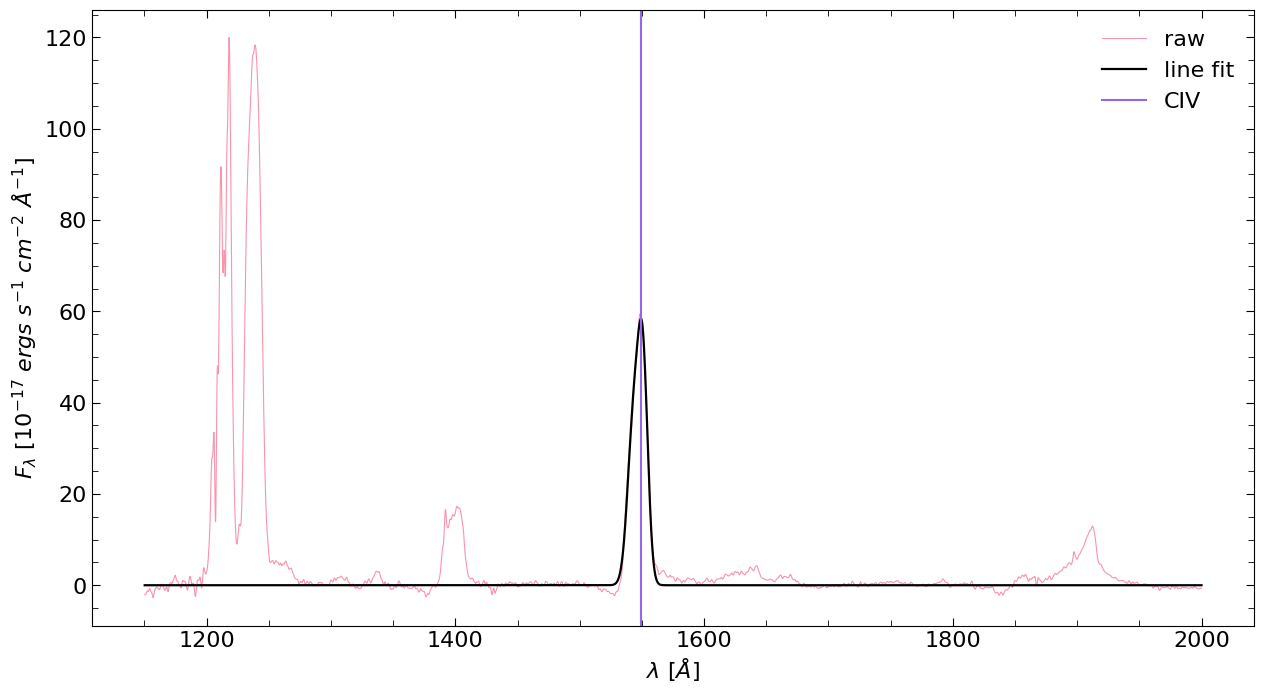


                SDSS: 131047.78+322518.3, DESI: 39632930762395245
                FWHM: 2872.15 vs 2793.839 (Hamann)
                REW: 244.258 vs 226.394 (Hamann)
                kt80: 0.385 vs 0.367 (Hamann)
                flux: 880.104 vs 925.713 (DESI)
    
---------------------------------------
---------------------------------------


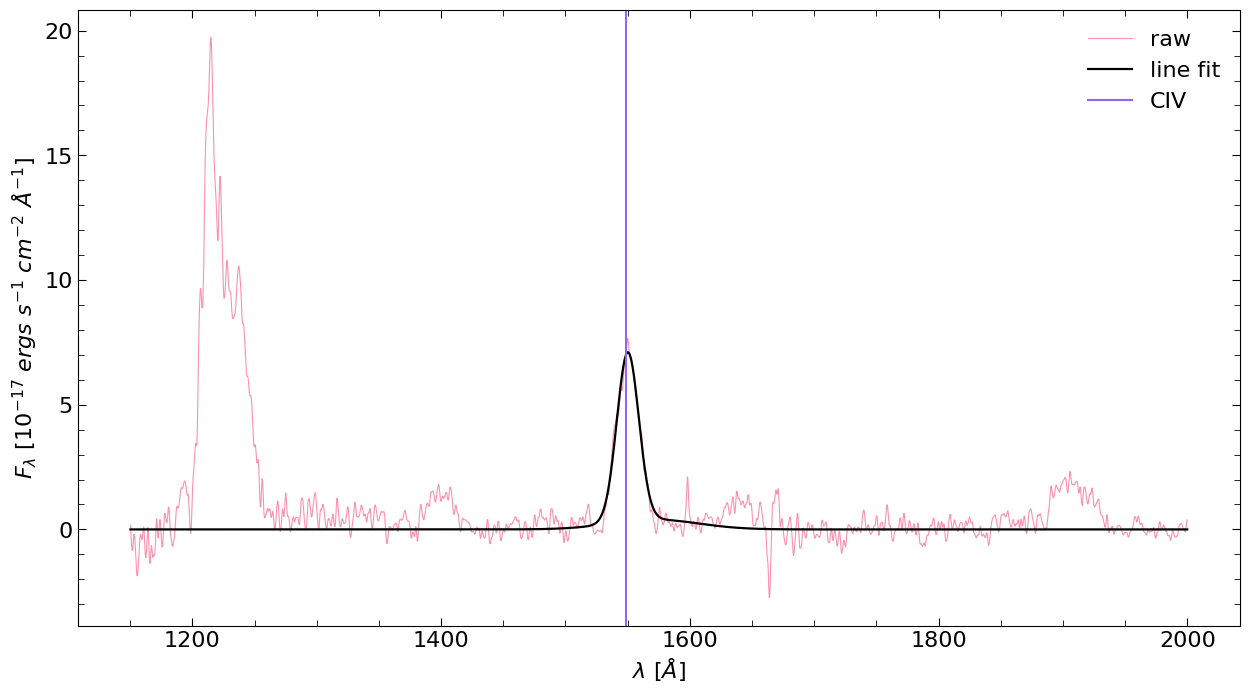


                SDSS: 221524.00-005643.8, DESI: 39627766169079016
                FWHM: 4150.683 vs 4280.102 (Hamann)
                REW: 237.049 vs 153.336 (Hamann)
                kt80: 0.36 vs 0.366 (Hamann)
                flux: 192.779 vs 272.195 (DESI)
    
---------------------------------------
---------------------------------------


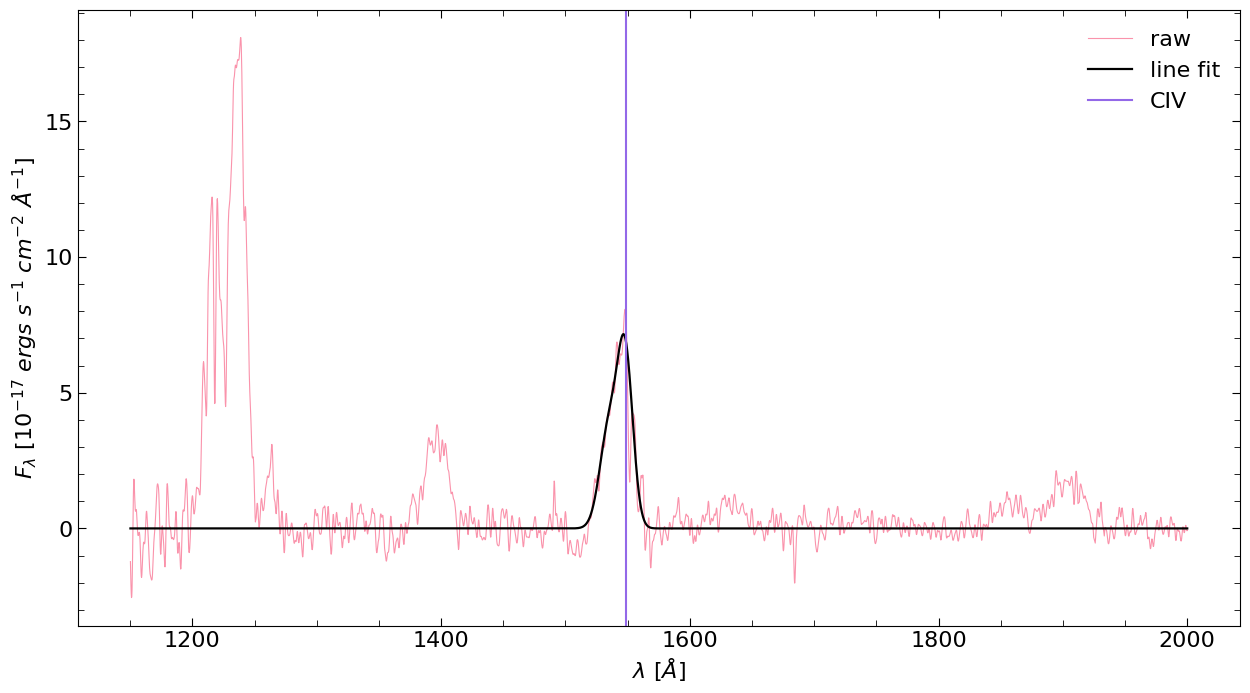


                SDSS: 134450.51+140139.2, DESI: 39628123335037135
                FWHM: 4401.333 vs 4487.034 (Hamann)
                REW: 144.121 vs 132.41 (Hamann)
                kt80: 0.324 vs 0.372 (Hamann)
                flux: 157.634 vs 179.483 (DESI)
    
---------------------------------------
---------------------------------------


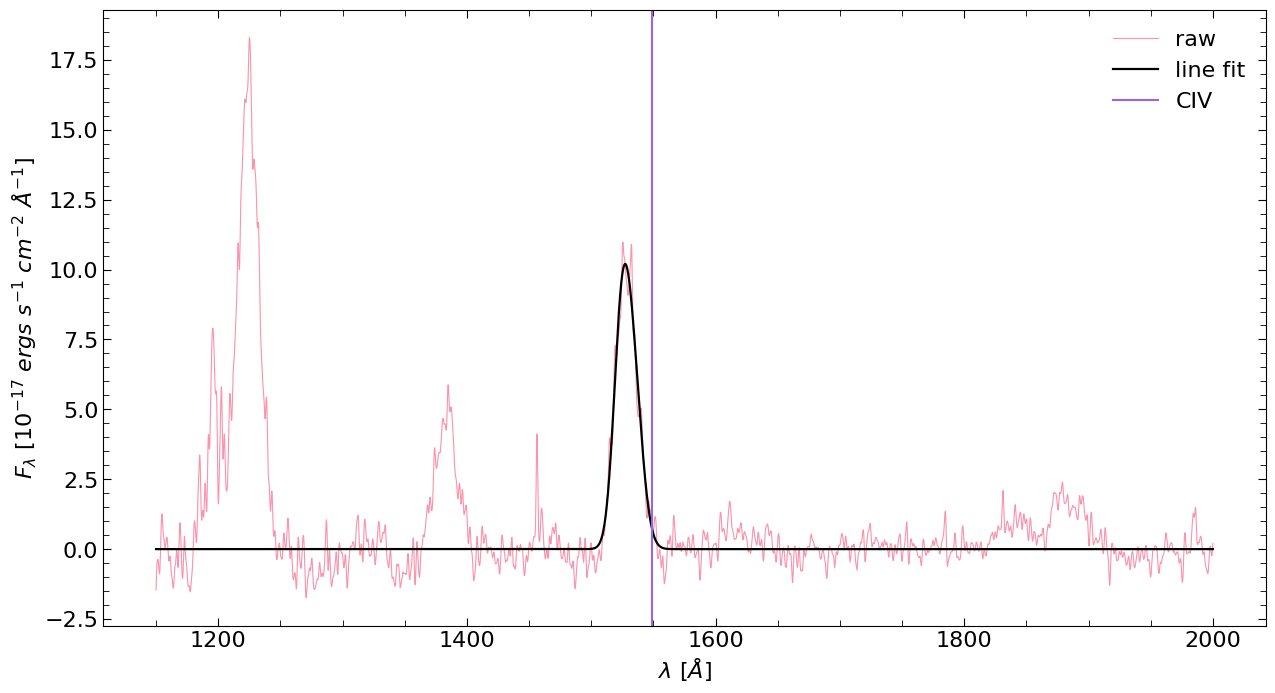


                SDSS: 153107.14+105825.8, DESI: 39628052950420499
                FWHM: 4013.428 vs 3936.554 (Hamann)
                REW: 168.336 vs 151.904 (Hamann)
                kt80: 0.383 vs 0.372 (Hamann)
                flux: 221.574 vs 1.086 (DESI)
    
---------------------------------------
---------------------------------------


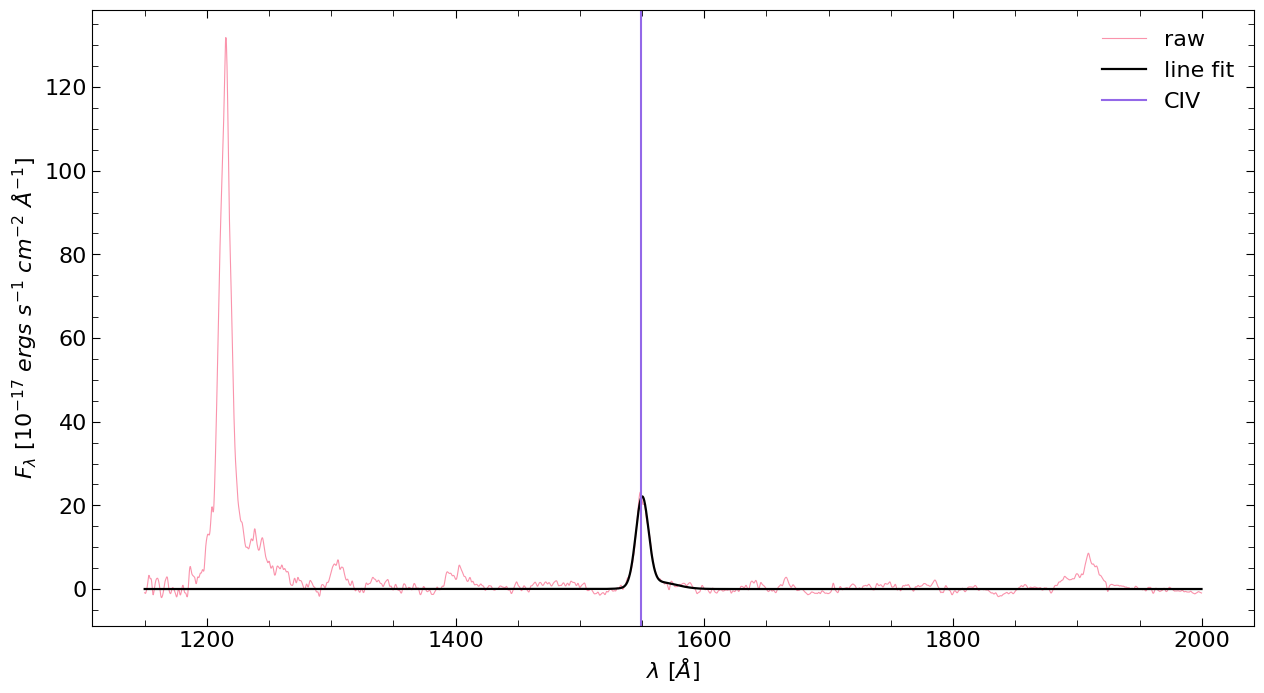


                SDSS: 104718.35+484433.8, DESI: 39633228125965823
                FWHM: 2393.445 vs 2521.46 (Hamann)
                REW: 175.504 vs 158.03 (Hamann)
                kt80: 0.358 vs 0.361 (Hamann)
                flux: 328.933 vs 310.697 (DESI)
    
---------------------------------------
---------------------------------------


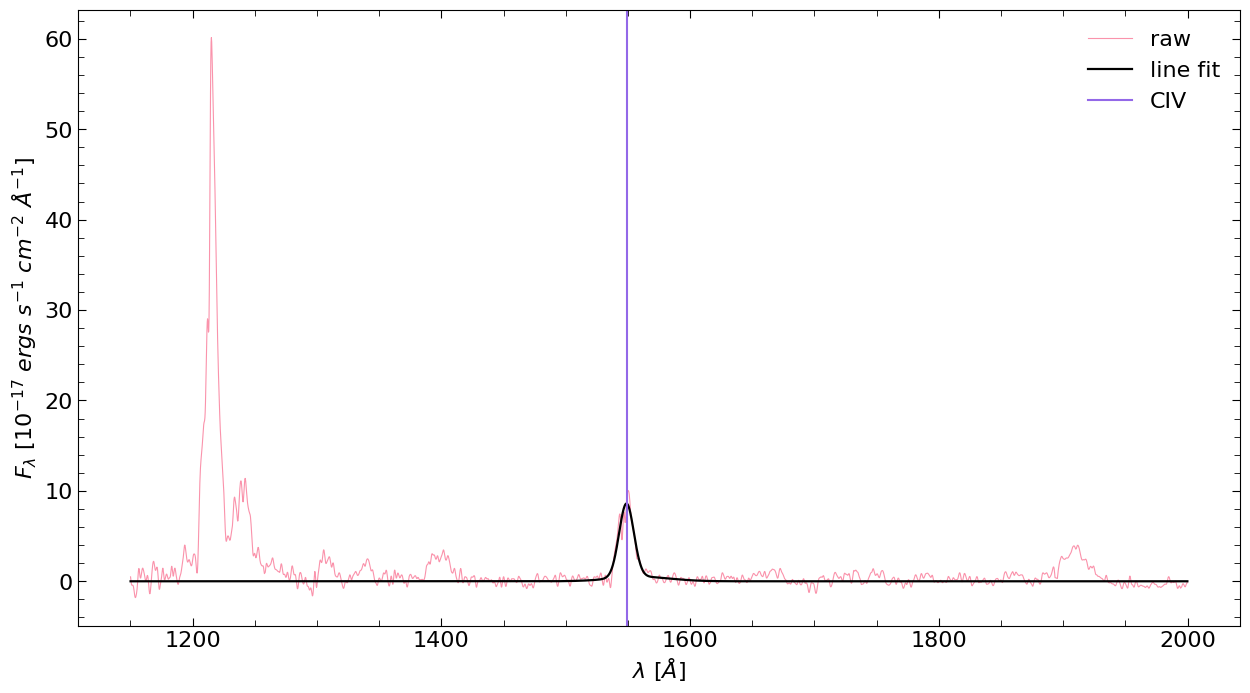


                SDSS: 020932.15+312202.7, DESI: 39628504643403849
                FWHM: 2794.73 vs 2180.064 (Hamann)
                REW: 132.219 vs 107.677 (Hamann)
                kt80: 0.359 vs 0.345 (Hamann)
                flux: 145.573 vs 160.998 (DESI)
    
---------------------------------------
---------------------------------------


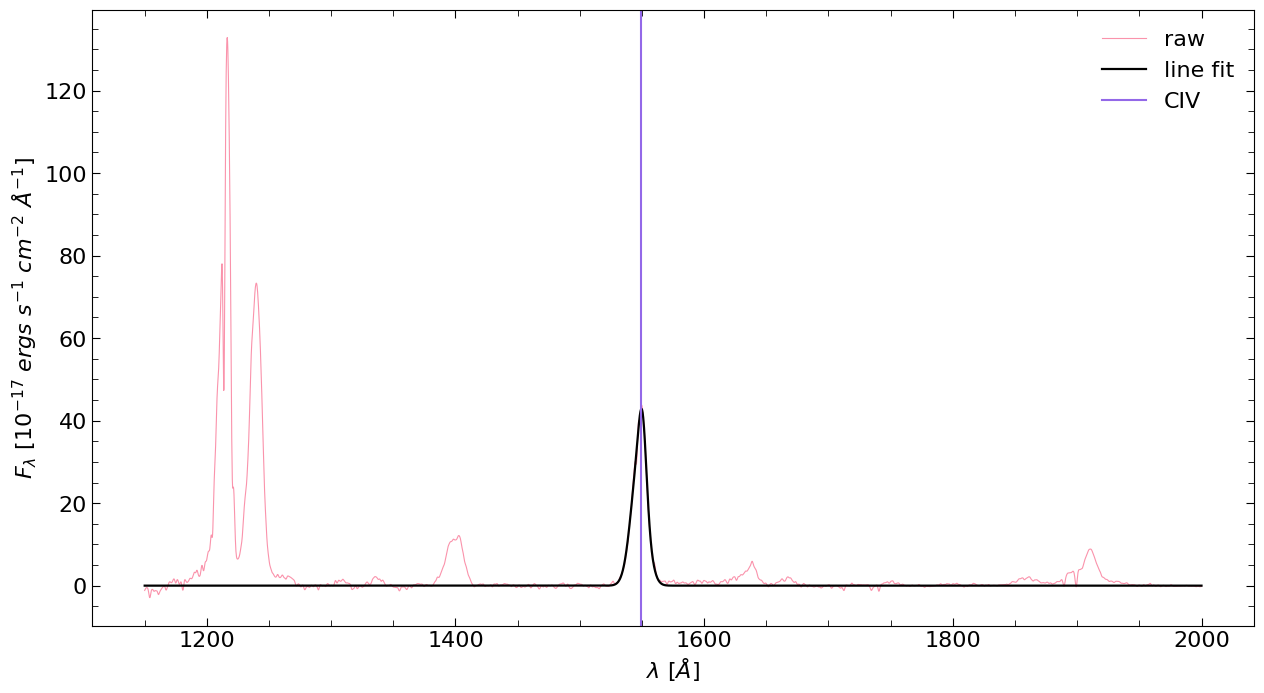


                SDSS: 082653.42+054247.3, DESI: 39627925623935704
                FWHM: 2412.032 vs 2433.822 (Hamann)
                REW: 233.539 vs 204.619 (Hamann)
                kt80: 0.314 vs 0.358 (Hamann)
                flux: 587.843 vs 624.157 (DESI)
    
---------------------------------------
---------------------------------------


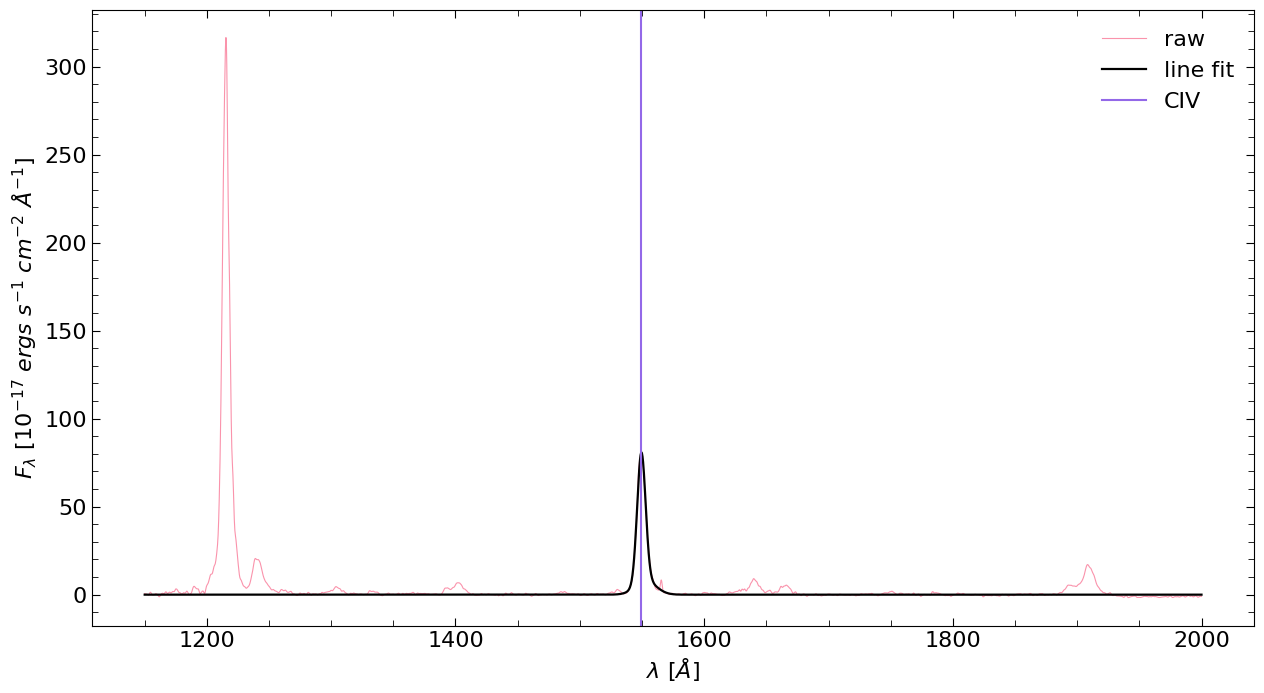


                SDSS: 232828.47+044346.8, DESI: 39627905315113841
                FWHM: 1624.715 vs 1583.693 (Hamann)
                REW: 415.714 vs 358.596 (Hamann)
                kt80: 0.354 vs 0.352 (Hamann)
                flux: 783.67 vs 882.327 (DESI)
    
---------------------------------------
---------------------------------------
SDSS: 160431.55+563354.2, DESI: 39633342928259345
Rejected because: Continuum too steep (alpha=3.79)


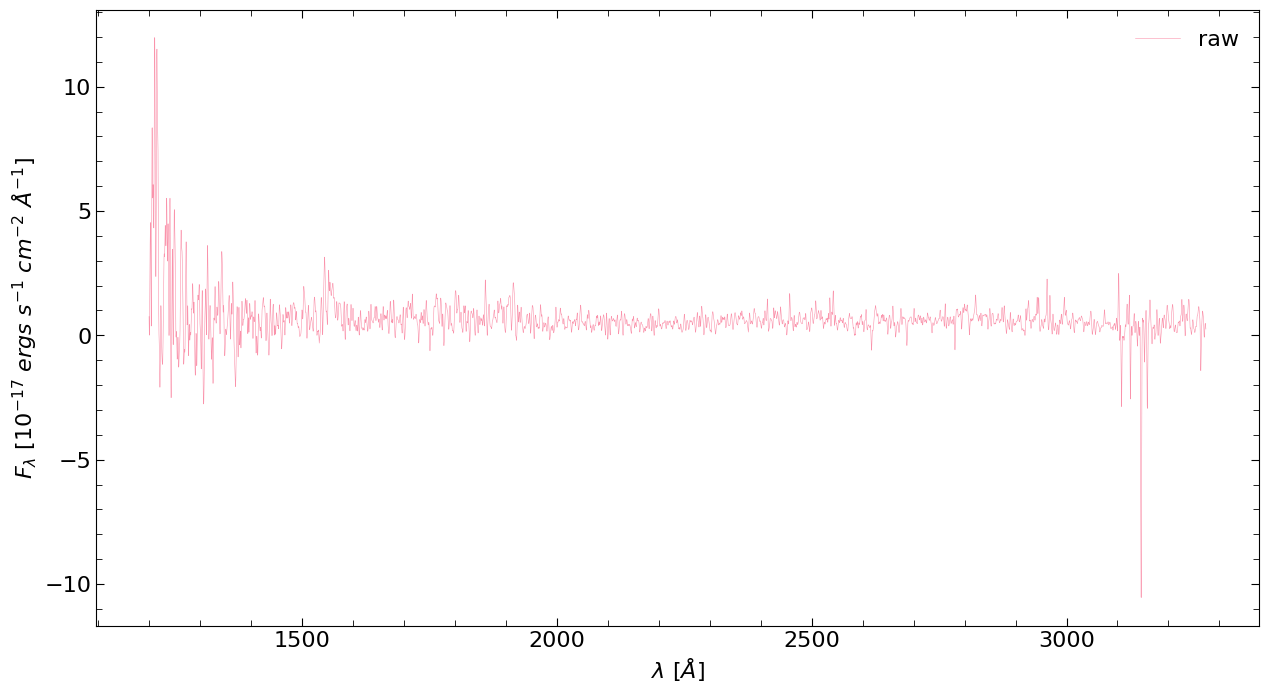

---------------------------------------
---------------------------------------


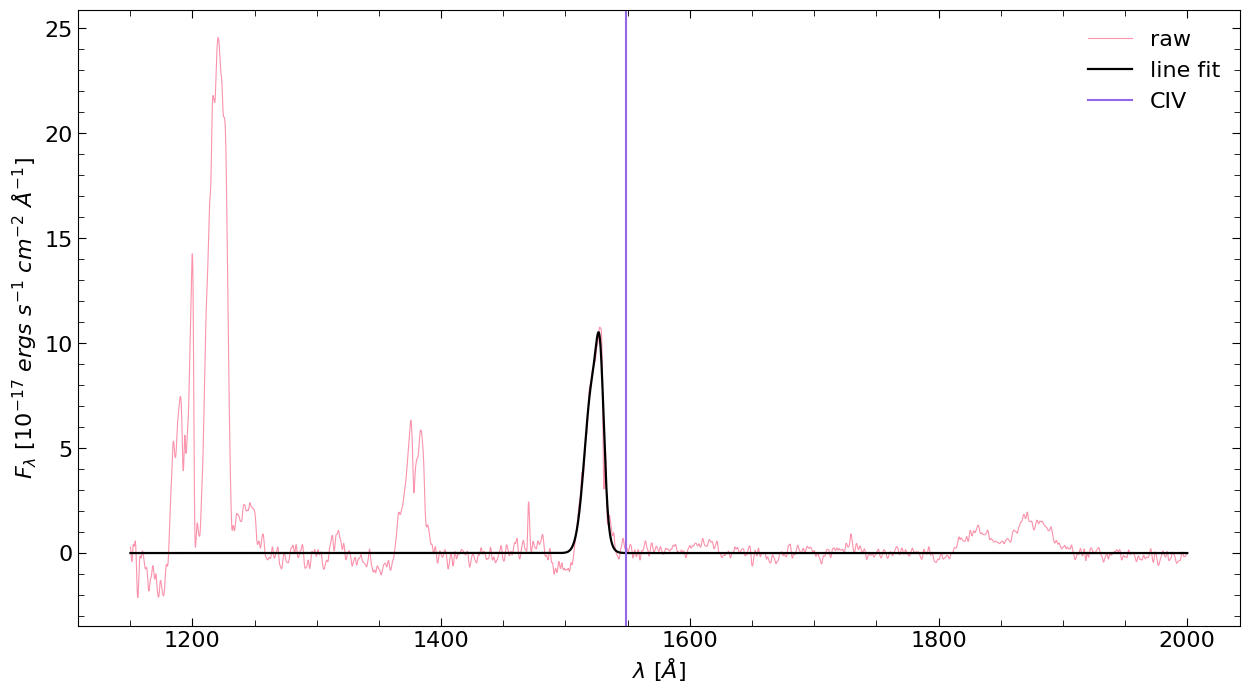


                SDSS: 154831.92+311951.4, DESI: 39628507583615618
                FWHM: 2977.828 vs 3050.048 (Hamann)
                REW: 127.351 vs 127.184 (Hamann)
                kt80: 0.357 vs 0.372 (Hamann)
                flux: 163.635 vs 3.494 (DESI)
    
---------------------------------------
---------------------------------------


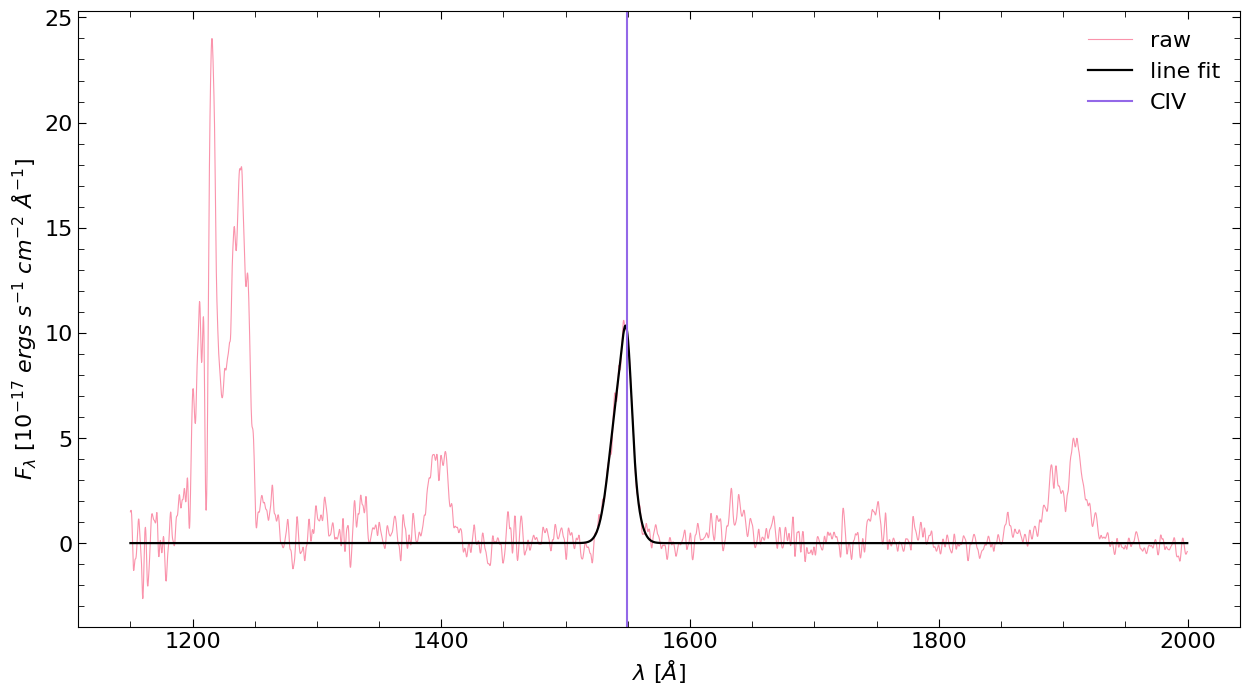


                SDSS: 080547.66+454159.0, DESI: 39633178285048118
                FWHM: 3351.428 vs 2667.071 (Hamann)
                REW: 168.679 vs 108.69 (Hamann)
                kt80: 0.309 vs 0.211 (Hamann)
                flux: 191.578 vs 242.485 (DESI)
    
---------------------------------------
---------------------------------------


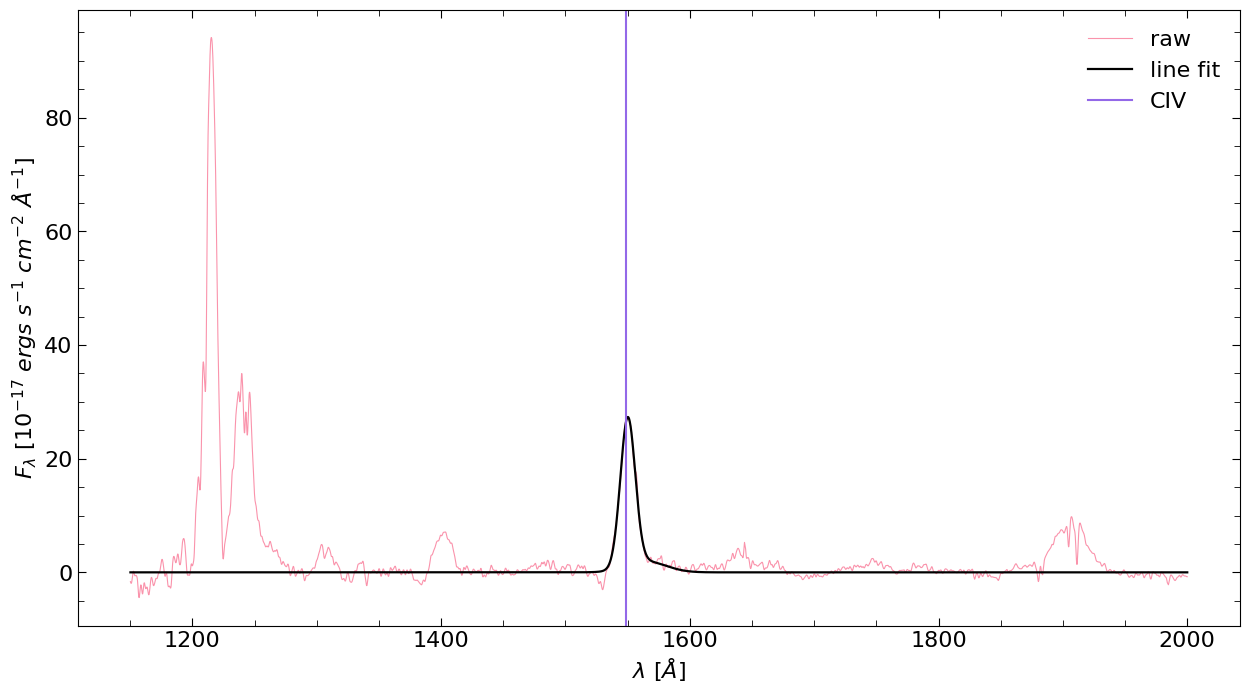


                SDSS: 014111.13-031852.5, DESI: 39627706643513715
                FWHM: 2816.662 vs 2985.648 (Hamann)
                REW: 119.08 vs 101.008 (Hamann)
                kt80: 0.36 vs 0.372 (Hamann)
                flux: 465.827 vs 436.53 (DESI)
    
---------------------------------------
---------------------------------------


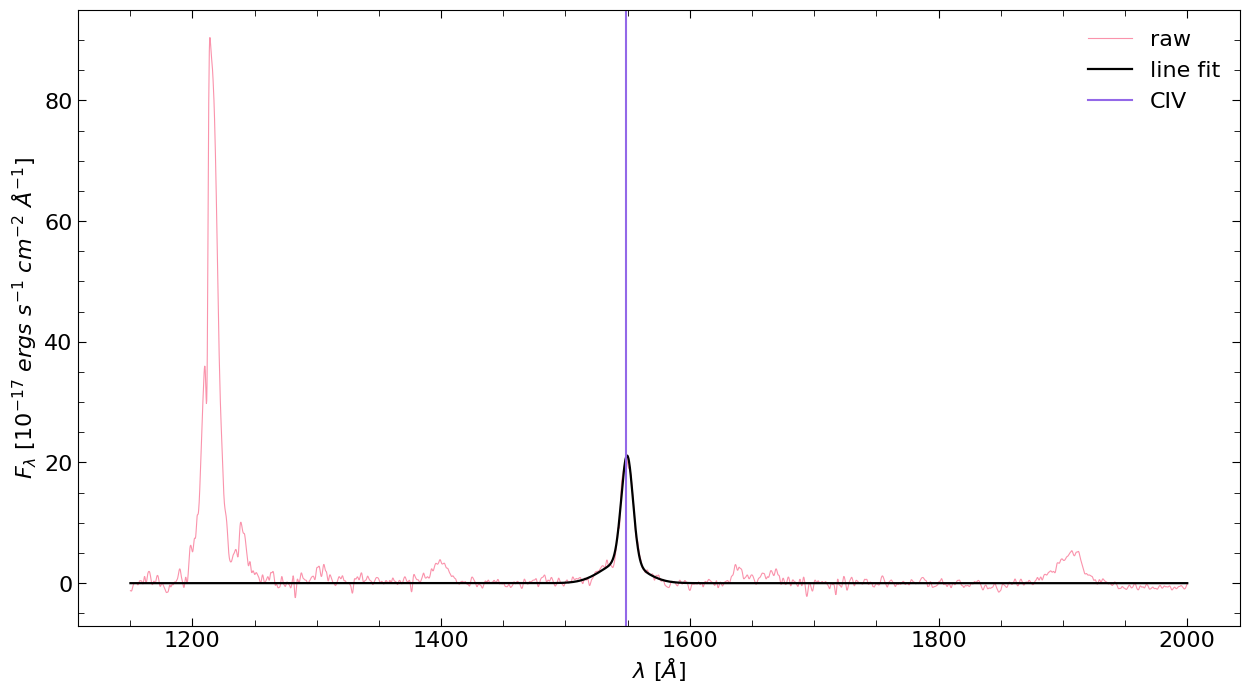


                SDSS: 000746.19+122223.9, DESI: 39628078770555722
                FWHM: 2389.46 vs 2432.83 (Hamann)
                REW: 234.029 vs 219.634 (Hamann)
                kt80: 0.324 vs 0.284 (Hamann)
                flux: 347.665 vs 382.848 (DESI)
    
---------------------------------------
---------------------------------------


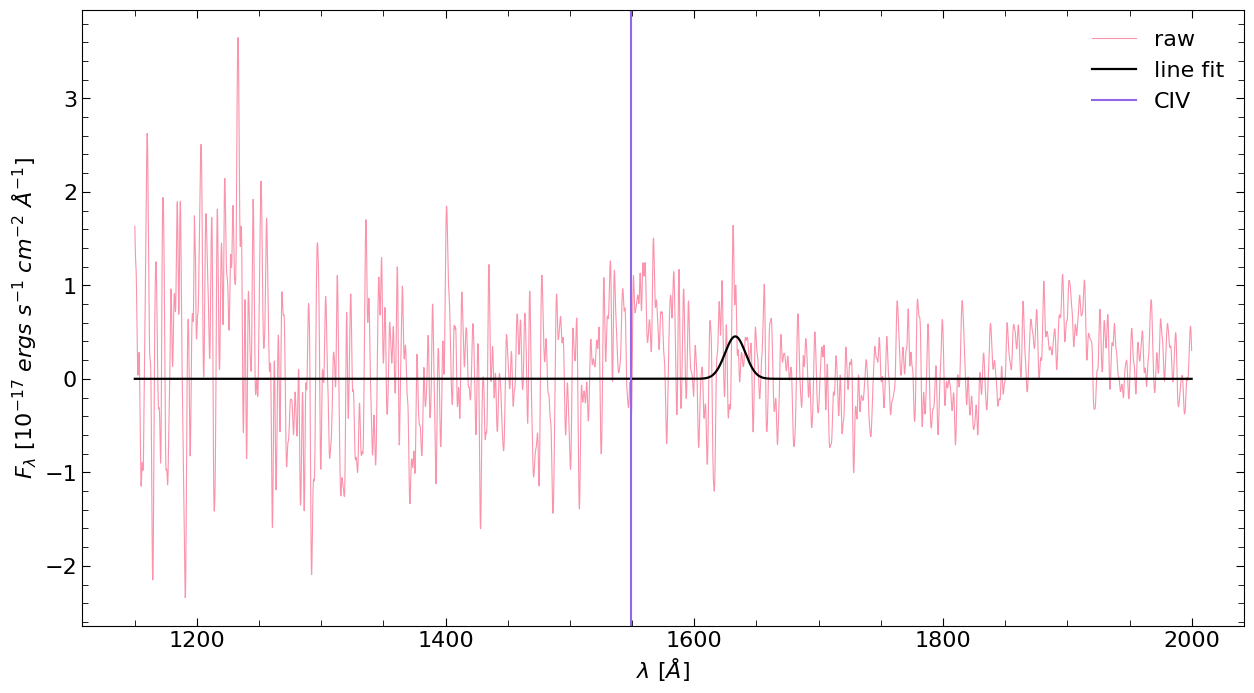


                SDSS: 134417.34+445459.4, DESI: 39633162216670370
                FWHM: 3747.539 vs 2870.515 (Hamann)
                REW: 30.524 vs 309.962 (Hamann)
                kt80: 0.372 vs 0.36 (Hamann)
                flux: 7.453 vs 30.334 (DESI)
    
---------------------------------------
---------------------------------------


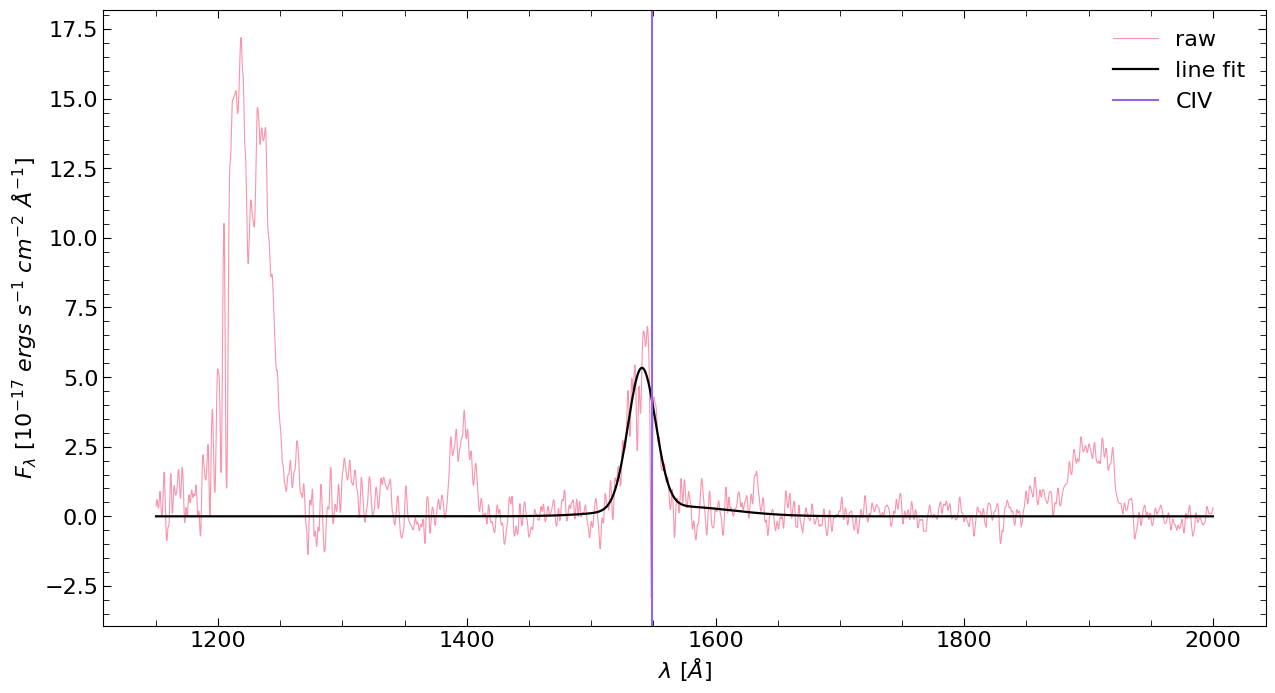


                SDSS: 085451.11+173009.1, DESI: 39628203643371939
                FWHM: 5243.015 vs 4199.357 (Hamann)
                REW: 149.076 vs 120.014 (Hamann)
                kt80: 0.358 vs 0.37 (Hamann)
                flux: 172.267 vs 223.233 (DESI)
    
---------------------------------------
---------------------------------------


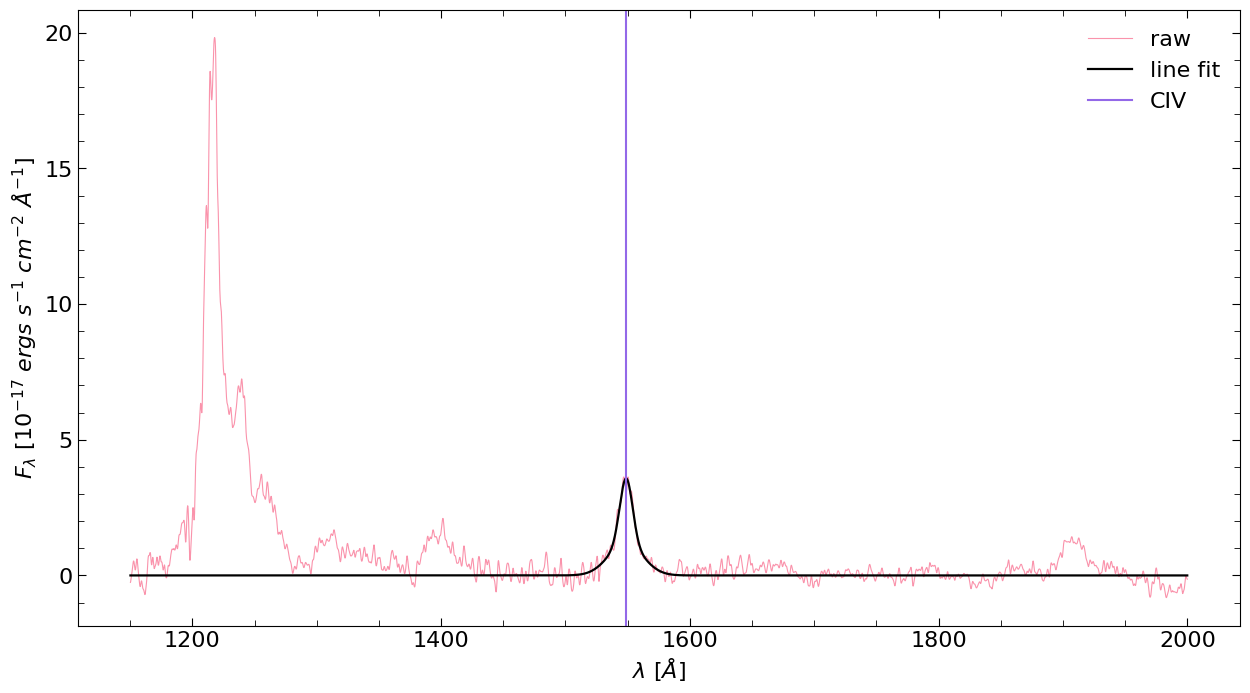


                SDSS: 102447.32-013633.8, DESI: 39627751107334558
                FWHM: 2956.612 vs 2843.202 (Hamann)
                REW: 95.965 vs 192.349 (Hamann)
                kt80: 0.283 vs 0.148 (Hamann)
                flux: 70.963 vs 90.278 (DESI)
    
---------------------------------------
---------------------------------------


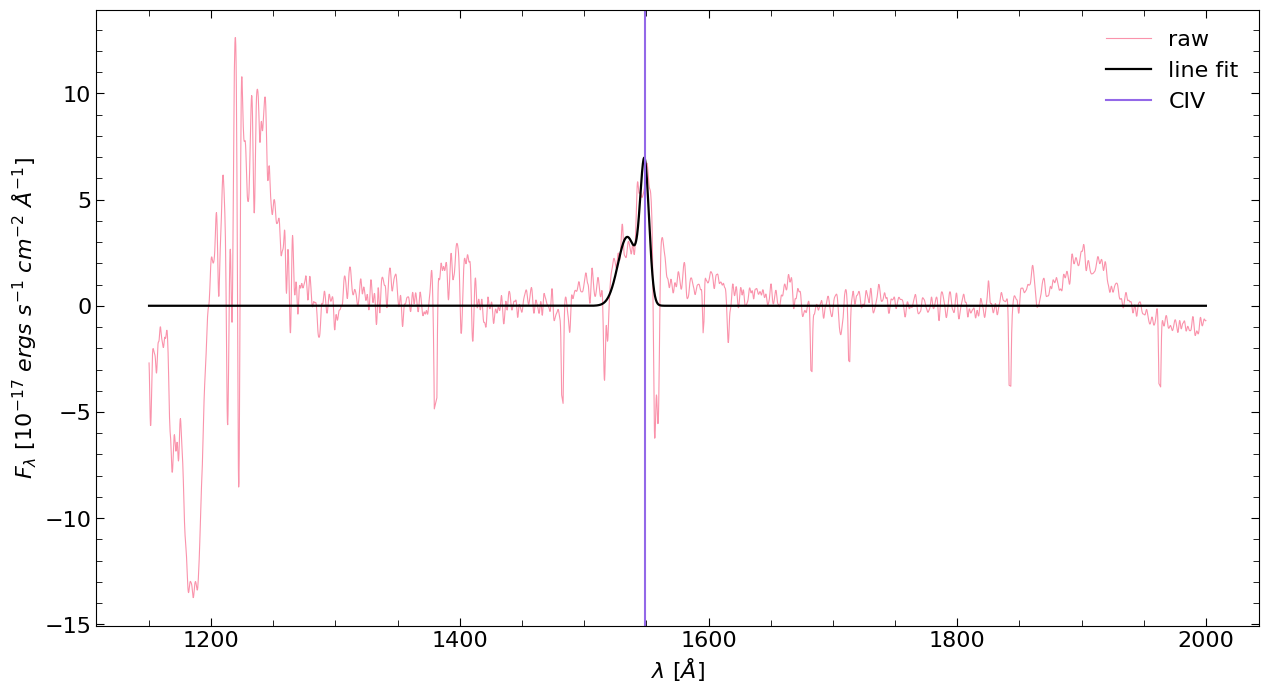


                SDSS: 005233.24-055653.5, DESI: 39627640176382892
                FWHM: 1908.246 vs 2450.95 (Hamann)
                REW: 17.036 vs 188.145 (Hamann)
                kt80: 0.173 vs 0.274 (Hamann)
                flux: 97.714 vs 159.336 (DESI)
    
---------------------------------------
---------------------------------------


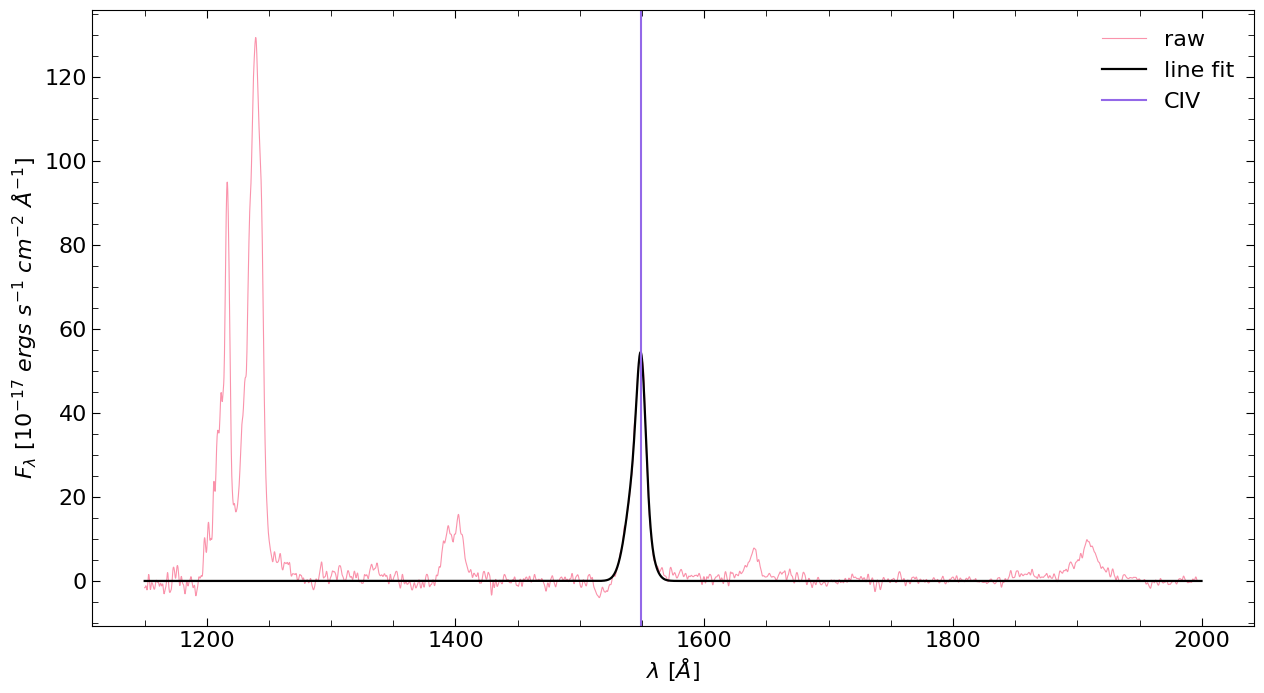


                SDSS: 165202.64+172852.3, DESI: 39628205555974657
                FWHM: 2335.273 vs 2403.322 (Hamann)
                REW: 196.18 vs 124.521 (Hamann)
                kt80: 0.284 vs 0.329 (Hamann)
                flux: 781.354 vs 905.182 (DESI)
    
---------------------------------------
---------------------------------------


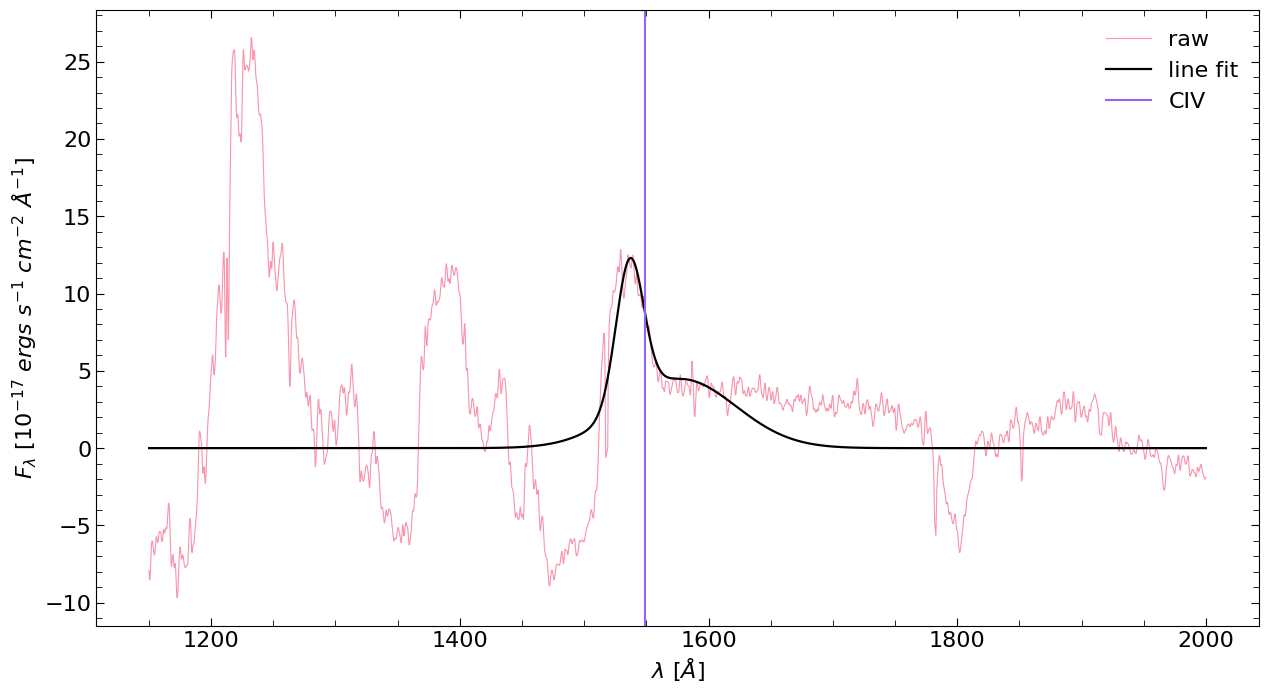


                SDSS: 153108.10+213725.1, DESI: 39628296442347665
                FWHM: 6465.413 vs 2766.583 (Hamann)
                REW: 41.479 vs 212.521 (Hamann)
                kt80: 0.154 vs 0.26 (Hamann)
                flux: 451.636 vs 598.0 (DESI)
    
---------------------------------------
---------------------------------------


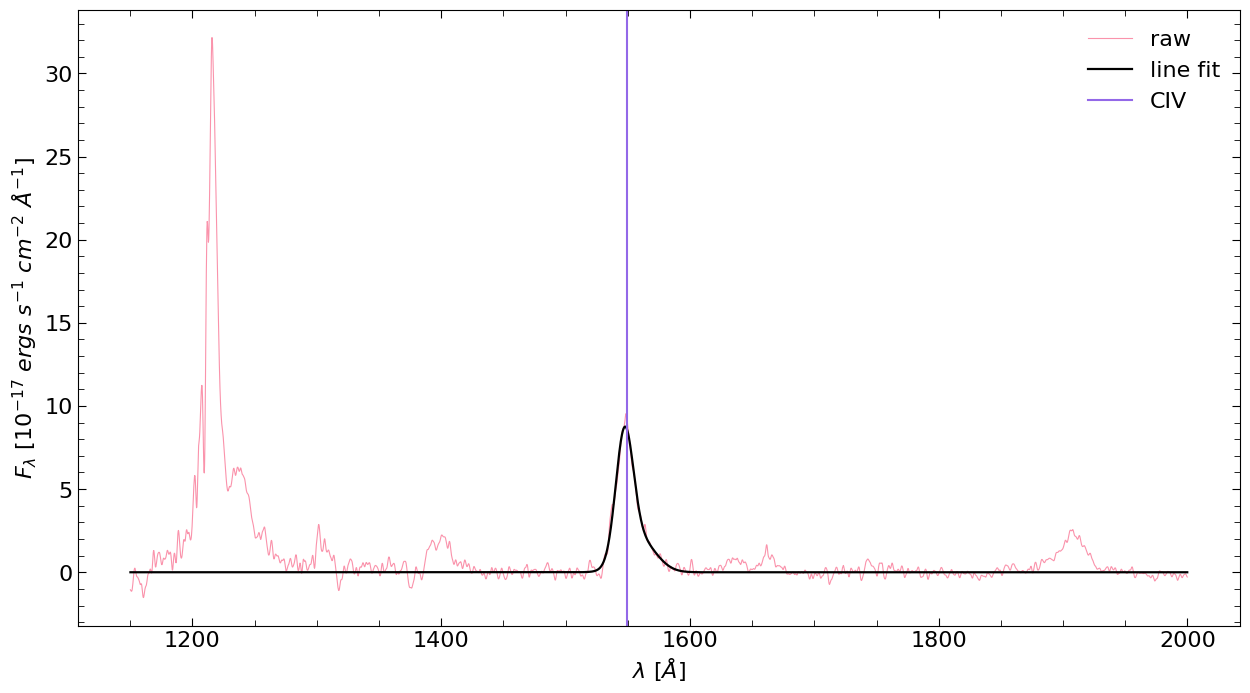


                SDSS: 110202.68-000752.7, DESI: 39627787501309795
                FWHM: 3611.062 vs 3766.854 (Hamann)
                REW: 89.882 vs 120.732 (Hamann)
                kt80: 0.314 vs 0.179 (Hamann)
                flux: 194.043 vs 229.732 (DESI)
    


In [22]:
for i in range(len(spectra_df)):
    print("---------------------------------------\n---------------------------------------")
    sanity_tests(i)